UPscaledEV Project Main Code
Under the funding from TotalEnergies
Author: Yizhan Gu
Email: yig031@ucsd.edu
Affiliation: UCSD CER

Readme:
This code aims at formulating a complex optimization framework with DERs of building, EV, PV and BESS, to solve a value-stacking problem with wholesale market and demand response market participation. It's based on Yi-An Chen's sclaedev codd and more consice, robust and well-constructed.

Labels:
NOTE: means there's a note and please read it
FIXME: means it's a bug or a problem that needs solving
TODO: means it's a to-do task, but not critical to the code running
VERSION: means there're more than one version for the diversity purpose, possibly shows in objective function choices or results analyses

Acknowledgement:
I gratefully acknowledge the support from my PI Jan Kleissl and TotalEnergies team, and the contributions from Yi-An Chen, whose prior work laid the foundation for this project. Special thanks to the UCSD Grid Lab team members.

Set working path and import packages

In [102]:
import os
os.chdir('/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024') 
print("Path is:", os.getcwd(), "\n")

import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from datetime import timedelta
from datetime import datetime
import time
from time import process_time
import calendar
import holidays
from pathlib import Path
import cvxpy as cp
import sys
from forecast_ED_PD import KnownUser, UnKnownUser
import glob
import warnings
from tqdm import tqdm
import gurobipy as gp
import seaborn as sns

Path is: /Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024 



Parameters

In [ ]:
# MPC parameters
dt_m_EV = 15
dt_h = dt_m_EV/60
interval = timedelta(minutes=dt_m_EV)
unit = dt_h

# Energy Prices-AL-TOU:
# SG&E 6/1 - 10/31 Summer: off-peak period energy charge rate $0.10679/kW h
#         On-peak period energy charge rate $0.12628/kW h
# Else Winter: off-peak period energy charge rate $0.09506/kW h
#         On-peak period energy charge rate $0.10626/kW h
c_e_TOU_AL = np.ones((96, 1))*0.10679
c_e_TOU_AL[16*4:21*4] = 0.12628
# TODO: Add Winter rates and auto for days


# Demand Charges
c_NCD = 24.48  #24.48*0.25=6.12
c_PD = 19.14 + 9.78

# Tax
c_tax_DWR = 0.00580                               # x Total kWh
c_tax_oEESbo_Franchise = 0.0688 * c_tax_DWR       # x Total kWh
c_tax_CA_Surcharge = 0.00030                      # x Total kWh
c_tax_CA_Regulatory = 0.00058                     # x Total kWh
# x Total Bill (UDC+Commodity)
c_tax_SD_Franchise = 0.0578
c_tax_all = c_tax_DWR + c_tax_oEESbo_Franchise + c_tax_CA_Surcharge + c_tax_CA_Regulatory


# Forecast methods
Numb_EVs = 0
Numb_AbsDiffEVs = 0

Fc_SessionkWh = 'PerfectSessionkWh'  # 'PerfectSessionkWh' #'PersistenceSessionkWh'
Fc_NumbEV = 'PerfectNumbEV'          # 'PerfectNumbEV'     #'PersistenceNumbEV'
Fc_AtArrival = 'PerfectatArrival'    # 'PerfectatArrival'  #'MLatArrival' from Avik
Fc_building = 'Perfect'              # 'Perfectat'  #'Persistence'
Fc_PV = 'Perfect'                    # 'Perfectat'  #'Persistence'

# NOTE: to get the Dispatch file before baseline calculation, run the baseline.py file before running this file
DAM = 1 # 1/0: w/o day-ahead market participation (Demand Response)

#always run both the base case (no service level reduction) and the case1 with service level reduction
Cases = ['Base', 'Case1']

year = 2025

Data processing

In [118]:
if Fc_AtArrival == 'MLatArrival':
    User_Data = pd.read_csv("Driver_Table.csv")
    User_known = User_Data['driver_id'][User_Data['TotSession']>10].unique()
    UserNoBess = []


# create weekdays (excluding holidays) and weekends (including holidays) lists
Holidays = holidays.US()
Holidays_dates = list(Holidays.keys())
Holidays_dates = [date for date in Holidays_dates if date.year == year]

datetime(year,1,1) in Holidays
start_ind_Y = datetime(year,1,1)
end_ind_Y = datetime(year+1,1,1)
DateSeries_ThisY = []
while start_ind_Y < end_ind_Y:
    DateSeries_ThisY.append(start_ind_Y)
    start_ind_Y += timedelta(hours=24)

DateSeries_ThisY = pd.Series(DateSeries_ThisY)
Y_Weekends = DateSeries_ThisY[DateSeries_ThisY.dt.dayofweek>=5]
Y_Holidays = DateSeries_ThisY[DateSeries_ThisY.dt.date.isin(Holidays_dates)]

Y_WeekendsWH = pd.concat([Y_Weekends,Y_Holidays],axis=0).drop_duplicates(keep='first', inplace=False).sort_values(axis=0, ascending=True).reset_index(drop=True)
Y_WeekdaysWOH = DateSeries_ThisY[~(DateSeries_ThisY.isin(Y_WeekendsWH))].sort_values(axis=0, ascending=True).reset_index(drop=True)
if len(Y_WeekdaysWOH) + len(Y_WeekendsWH) != len(DateSeries_ThisY):
    print("Error in holiday identification!\n")
    sys.exit()


# VERSION: 2025 EV data
Data = pd.read_csv('2025Data/EV_data/UCSD_AllSites_Merge_PostProcessedSession_QC.csv', low_memory=False)
Data['Interval start'] = pd.to_datetime(Data['Interval start'])
Data['Interval end'] = pd.to_datetime(Data['Interval end'])
Data['Session start'] = pd.to_datetime(Data['Session start'])
Data['Session end'] = pd.to_datetime(Data['Session end'])
Data['Interval max demand kW'] = pd.to_numeric(Data['Interval max demand kW'], errors='coerce')
Data['Interval average demand kW'] = pd.to_numeric(Data['Interval average demand kW'], errors='coerce')


print("Number of Intervals:", len(Data))
print("Test year:", year)
print("Date range:", Data['Interval start'].min(), "to", Data['Interval start'].max())
print("Unique sites:", len(Data['Site'].unique()))
Data['Car_'] = Data['10-digit UID'].astype(str)


# Read baseline data
dir_Input = os.path.join('Results/Dispatch')
filename_Input = dir_Input + '/2025_'+Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival +'_baseline.csv'
Dispatch_2025_baseline = pd.read_csv(filename_Input, low_memory=False, header = 0)           
Dispatch_2025_baseline['Interval start'] = pd.to_datetime(Dispatch_2025_baseline['Interval start'])

    

Number of Intervals: 374890
Test year: 2025
Date range: 2025-01-01 03:15:00 to 2025-07-31 21:00:00
Unique sites: 23


In [ ]:
# FIXME: 2025 Baseline not in use

# TODO: need to add building and PV and BESS to update the baseline, and first days there are no implementation csvs?
dir_Input = os.path.join('Other/Trash_data')
filename_Input = dir_Input + '/2022_'+Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival +'_MonthlyTh_Eta_v5_test4.csv'

Dispatch_2025 = pd.read_csv(filename_Input)

# make sure dropping the earlier data for duplicated rows                
Dispatch_2025['Interval start'] = pd.to_datetime(Dispatch_2025['Interval start'])
Dispatch_2025 = Dispatch_2025.drop_duplicates('Interval start',keep='last')


Day0_temp = datetime(2022, 12, 1)
Dispatch_day0 = Dispatch_2025[(Dispatch_2025['Interval start'] >= Day0_temp) & (Dispatch_2025['Interval start'] < Day0_temp + timedelta(days=1))]
Dispatch_day0 = Dispatch_day0.reset_index()
Dispatch_preceding = Dispatch_2025[(Dispatch_2025['Interval start'] >= Day0_temp - timedelta(days=45)) & (Dispatch_2025['Interval start'] < Day0_temp)]
Dispatch_preceding.loc[:, "hms"] = Dispatch_preceding["Interval start"].dt.time

# TODO: replace with the real event hours from DSGS (but its unavailable in 2025)
Eventhour_example = np.zeros(24, dtype=int)
Eventhour_example[15:20] = 1
# Only happens 15:00--22:00
Eventhour_example[0:14] = 0
Eventhour_example[22:23] = 0

# TODO: now it's a simplified version, need to add more filter with DR cases of preceding days
if Day0_temp in list(Y_WeekendsWH):
    N_days = 4
    Dispatch_preceding = Dispatch_preceding[Dispatch_preceding['Interval start'].dt.date.isin(Y_WeekendsWH.dt.date)]
else:
    N_days = 10
    Dispatch_preceding = Dispatch_preceding[~Dispatch_preceding['Interval start'].dt.date.isin(Y_WeekendsWH.dt.date)]
    

# Filter to only include the last N_days days in Dispatch_preceding
last_dates = sorted(Dispatch_preceding['Interval start'].dt.date.unique())[-N_days:]
Dispatch_preceding = Dispatch_preceding[Dispatch_preceding['Interval start'].dt.date.isin(last_dates)]


Load_avg = (
    Dispatch_preceding.groupby("hms")["V1G_real [kWh]"]
    .mean()
    .reset_index()
    .rename(columns={"V1G_real [kWh]": "Load_avg"})
)
Load_avg_hourly = Load_avg["Load_avg"].values.reshape(24, 4).mean(axis=1) * 4
Load_Day0_real_hourly = Dispatch_day0["V1G_real [kWh]"].values.reshape(24, 4).mean(axis=1) * 4
Load_Day0_V0G_hourly = Dispatch_day0["V0G [kWh]"].values.reshape(24, 4).mean(axis=1) * 4
Load_Baseline_hourly = pd.DataFrame({
    "Hour": range(24),
    "EB": Load_avg_hourly,
    "Day0_real": Load_Day0_real_hourly,
    "Event": Eventhour_example,
    "V0G": Load_Day0_V0G_hourly,
    "DOAV": np.zeros(24, dtype=float),
    "Ratio_AS": np.zeros(24, dtype=float)  # Initialize Ratio with zeros
})

# DOAV calculation
# Ratio of the average of the H-2, H-3 and H-4 Day0's / N days' load before each event hour H
event_hours = Load_Baseline_hourly.loc[Load_Baseline_hourly["Event"] == 1, "Hour"].values

# Loop through each event hour
for event_hour in event_hours:
    DOAV_hours = range(event_hour - 4, event_hour - 1)  # includes hours [event_hour-4, event_hour-2]
    DOAV = sum(Load_Baseline_hourly.loc[DOAV_hours, "Day0_real"]) / sum(Load_Baseline_hourly.loc[DOAV_hours, "EB"])
    if sum(Load_Baseline_hourly.loc[DOAV_hours, "Day0_real"]) < 0 or sum(Load_Baseline_hourly.loc[DOAV_hours, "EB"]) < 0:
        DOAV = 1
    DOAV = min(max(DOAV, 0.6), 1.4)  # Ensure DOAV is within the range [0.6, 1.4] and keep 0s for non-event hours
    Load_Baseline_hourly.loc[Load_Baseline_hourly["Hour"] == event_hour, "DOAV"] = DOAV

Load_Baseline_hourly["AEB_DSGS"] = Load_Baseline_hourly["DOAV"] * Load_Baseline_hourly["EB"]

# Ratio_AS calculation
# Ratio of the average of the H-2, H-3 and H-4 Day0's / N days' load before each hour H from 4 to 23
for h in range(4, 24):
    Load_Baseline_hourly.loc[Load_Baseline_hourly["Hour"] == h, "Ratio_AS"] = (
        Load_Baseline_hourly.loc[Load_Baseline_hourly["Hour"].isin(range(h - 4, h - 1)), "Day0_real"].mean()
        / Load_Baseline_hourly.loc[Load_Baseline_hourly["Hour"].isin(range(h - 4, h - 1)), "EB"].mean()
    )
# FIXME: can I use last day's last hours for avg?
# For H = 1, 2, 3 just take the average of the 0:H-1
for h in range(1, 4):
    Load_Baseline_hourly.loc[Load_Baseline_hourly["Hour"] == h, "Ratio_AS"] = (
        Load_Baseline_hourly.loc[Load_Baseline_hourly["Hour"].isin(range(0, h)), "Day0_real"].mean()
        / Load_Baseline_hourly.loc[Load_Baseline_hourly["Hour"].isin(range(0, h)), "EB"].mean()
    )
# H = 0 no adjustment, just set it to 1
Load_Baseline_hourly.loc[Load_Baseline_hourly["Hour"] == 0, "Ratio_AS"] = 1
Load_Baseline_hourly["Ratio_AS"] = Load_Baseline_hourly["Ratio_AS"].clip(0.8, 1.2)
# Ensure no negative values
Load_Baseline_hourly["Ratio_AS"] = Load_Baseline_hourly["Ratio_AS"].clip(lower=0)
Load_Baseline_hourly["AEB_AS"] = Load_Baseline_hourly["Ratio_AS"] * Load_Baseline_hourly["EB"]

# TODO: add ratio in plots


# Plotting
y_top = Load_Baseline_hourly[["Day0_real", "V0G", "AEB_DSGS", "AEB_AS"]].max().max() * 1.05
df_event = Load_Baseline_hourly[Load_Baseline_hourly["Event"] == 1]

plt.figure(figsize=(12, 6))
plt.plot(Load_Baseline_hourly["Hour"], Load_Baseline_hourly["Day0_real"], label="Day0 (Real Load)", marker='o')
plt.plot(Load_Baseline_hourly["Hour"], Load_Baseline_hourly["V0G"], label="V0G (Dumb Charge)", marker='s')
plt.plot(Load_Baseline_hourly["Hour"], Load_Baseline_hourly["AEB_DSGS"], label="DSGS Baseline", linestyle='--')
plt.plot(Load_Baseline_hourly["Hour"], Load_Baseline_hourly["AEB_AS"], label="AS Baseline", linestyle='--')
plt.plot(df_event["Hour"], [y_top] * len(df_event), linestyle='', marker='x', color='lightcoral', label="DSGS Event Hour", markersize=12, markeredgewidth=2)

plt.xlabel(f"Hour of Day {Day0_temp.strftime('%Y-%m-%d')}", fontsize=16)
plt.ylabel("Load [kW]", fontsize = 16)
plt.title("Day0 EV Load & Baseline", fontsize = 18)
plt.grid(False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
Load_Baseline_hourly.to_csv(
    "/Other/Trash_data/Load_Baseline_hourly.csv",
    index=False
)
plt.savefig("/Other/Baseline.png", dpi=300)
plt.show()



Main Loop

In [ ]:
# clean all csv files presaved 
dir_Output = 'Results/Dispatch'
files = glob.glob(os.path.join(dir_Output, '[01]*'))
for file in files:
    if Path(file).exists():
        Path(file).unlink()
        
dir_Output = os.path.join('Results/Dispatch/' + '2025' +'_' +Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival  +'_implementation.csv')
filepath = Path(dir_Output)
if filepath.exists():
    filepath.unlink()
    

dir_Output = os.path.join('Results/Dispatch/' + '2025' +'_' +Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival  +'_daily_summary.csv')
filepath = Path(dir_Output)
if filepath.exists():
    filepath.unlink()
    
dir_Output = os.path.join('Results/Dispatch/' + '2025' +'_' +Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival  +'_daily_cost.csv')
filepath = Path(dir_Output)
if filepath.exists():
    filepath.unlink()

print("All dispatch files from last implementation have been deleted.\n")

Cost_All = pd.DataFrame()
start_time = time.time()  # record start time
test_month = 7

for month in np.array(range(1))+test_month:
    print("Test month:", month)
    num_days = calendar.monthrange(year,month)[1] 
    
    M_Th_NCD = [0 for _ in range(len(Cases)+1)]
    M_Th_PD = [0 for _ in range(len(Cases)+1)]
    M_Th_NCD_list = [[] for _ in range(len(Cases)+1)]
    M_Th_PD_list = [[] for _ in range(len(Cases)+1)]
    M_Th_NCD_list_96 = [[] for _ in range(len(Cases)+1)]
    M_Th_PD_list_96 = [[] for _ in range(len(Cases)+1)]
    
    
    M_V0G = pd.DataFrame()
    M_V1G = pd.DataFrame()
    M_Opt_Offline = pd.DataFrame()
    M_Opt_Imp = [pd.DataFrame() for _ in range(len(Cases))] #pd.DataFrame()
    M_t = pd.DataFrame()
    
    M_ED_V0G = []
    M_ED_V1G = []
    M_ED_Opt_DA = []
    M_ED_Opt_t0 = []
    M_ED_Opt_base = []
    M_ED_Opt_case1 = []
    
    if DAM == 1:
        M_baseline_Opt = pd.DataFrame()
    
    Status_list_DA = []
    revenue_WM_daily = 0
    for Day in tqdm(np.arange(1, num_days + 1), desc="Processing days"): # 1, num_days+1
        
        TheDate_Day0 = datetime(year, month, Day)   
        TheDate_Day0_Start = TheDate_Day0 + timedelta(seconds=0)
        TheDate_Day0_End = TheDate_Day0 + timedelta(hours=24)
        
        if len(Y_WeekdaysWOH[Y_WeekdaysWOH==TheDate_Day0])>0: 
            Order = Y_WeekdaysWOH[Y_WeekdaysWOH==TheDate_Day0].index  
            TheDate_Dayb1 = Y_WeekdaysWOH[Order-1].iloc[0]
            TheDate_Dayb2 = Y_WeekdaysWOH[Order-2].iloc[0]
            TheDate_Dayb3 = Y_WeekdaysWOH[Order-3].iloc[0]
        else:
            Order = Y_WeekendsWH[Y_WeekendsWH==TheDate_Day0].index  
            TheDate_Dayb1 = Y_WeekendsWH[Order-1].iloc[0]
            TheDate_Dayb2 = Y_WeekendsWH[Order-2].iloc[0]
            TheDate_Dayb3 = Y_WeekendsWH[Order-3].iloc[0]
            
        
        TheDate_Dayb1_Start = TheDate_Dayb1 + timedelta(seconds=0)
        TheDate_Dayb1_End   = TheDate_Dayb1 + timedelta(hours=24)
        TheDate_Dayb2_Start = TheDate_Dayb2 + timedelta(seconds=0)
        TheDate_Dayb2_End   = TheDate_Dayb2 + timedelta(hours=24)
        TheDate_Dayb3_Start = TheDate_Dayb3 + timedelta(seconds=0)
        TheDate_Dayb3_End   = TheDate_Dayb3 + timedelta(hours=24)

        TheDate        = [TheDate_Day0, TheDate_Dayb1, TheDate_Dayb2, TheDate_Dayb3]
        TheDates_Start = [TheDate_Day0_Start, TheDate_Dayb1_Start, TheDate_Dayb2_Start, TheDate_Dayb3_Start]
        TheDates_End   = [TheDate_Day0_End, TheDate_Dayb1_End, TheDate_Dayb2_End, TheDate_Dayb3_End]
        
        
        if DAM == 0:
            Bid_Pr_DA = np.zeros(96)
            Bid_Pr_RT = np.zeros(96)
            Baseline_Opt_avg = np.empty((3, 3, 24))


        # Read the LMP data
        dir_Input_DA = os.path.join("2025Data/LMP/2025/DA/")
        dir_Input_RT = os.path.join("2025Data/LMP/2025/FM/")

        filename_Input = glob.glob(dir_Input_DA + TheDate_Day0_Start.strftime('%Y%m%d') + '*.csv')
        Data_LMP_DA = pd.read_csv(''.join(filename_Input))
        filename_Input = glob.glob(dir_Input_RT + TheDate_Day0_Start.strftime('%Y%m%d') + '*.csv')
        Data_LMP_RT = pd.read_csv(''.join(filename_Input))
                
        Data_LMP_DA = Data_LMP_DA[Data_LMP_DA['LMP_TYPE']=='LMP']
        Data_LMP_RT = Data_LMP_RT[Data_LMP_RT['LMP_TYPE']=='LMP']
        
        # sort the 'INTERVALSTARTTIME_GMT'
        LMP_IntervalStartGMT_DA = Data_LMP_DA['INTERVALSTARTTIME_GMT']
        LMP_IntervalStartGMT_RT = Data_LMP_RT['INTERVALSTARTTIME_GMT']
        
        # sort LMP data based on the 'INTERVALSTARTTIME_GMT'    
        A = pd.to_datetime(LMP_IntervalStartGMT_DA)
        B = [k for k in range(len(A))]
        LMPOrder = [x for _, x in sorted(zip(A, B))]
        Data_LMP_DA_ = Data_LMP_DA.iloc[ LMPOrder, :]
        
        A = pd.to_datetime(LMP_IntervalStartGMT_RT)
        B = [k for k in range(len(A))]
        LMPOrder = [x for _, x in sorted(zip(A, B))]
        Data_LMP_RT_ = Data_LMP_RT.iloc[ LMPOrder, :]
        
        
        Bid_Pr_DA = np.array(Data_LMP_DA_['MW'].repeat(4)*0.001).reshape(96, 1)#repeat 4 times of the 24 x 1 series, $/MWh ---> $/kWh   
        Bid_Pr_RT = (np.average(np.array(Data_LMP_RT_['VALUE']).reshape(-1, 3), axis=1)*0.001).reshape(96, 1) #ave every 3 entries of the 288  x 1 series, $/MWh ---> $/kWh
        
        # Read the Ancillary Service prices data
        
        dir_AS_DA = os.path.join("2025Data/AS_DAM/")
        dir_AS_RT = os.path.join("2025Data/AS_RTM/")
        Data_AS_DA = pd.read_csv(dir_AS_DA + 'AS_price_2025_clear.csv')
        Data_AS_RT = pd.read_csv(dir_AS_RT + 'AS_price_2025_clear.csv')
        Data_AS_DA["datetime"] = pd.to_datetime(Data_AS_DA["datetime"])
        Data_AS_RT["datetime"] = pd.to_datetime(Data_AS_RT["datetime"])
        Data_AS_DA = Data_AS_DA[(Data_AS_DA["datetime"].dt.year == year) & (Data_AS_DA["datetime"].dt.month == test_month) & (Data_AS_DA["datetime"].dt.day == Day)].reset_index(drop=True)
        Data_AS_RT = Data_AS_RT[(Data_AS_RT["datetime"].dt.year == year) & (Data_AS_RT["datetime"].dt.month == test_month) & (Data_AS_RT["datetime"].dt.day == Day)].reset_index(drop=True)

        # Convert DA hourly AS prices to 15-min interval prices
        AS_Pr_RU_DA = np.repeat(Data_AS_DA["RegUp"].values, 4)
        AS_Pr_RD_DA = np.repeat(Data_AS_DA["RegDown"].values, 4)
        AS_Pr_SP_DA = np.repeat(Data_AS_DA["Spin"].values, 4)
        AS_Pr_NSP_DA = np.repeat(Data_AS_DA["NonSpin"].values, 4)

        # RT values does not need to be converted
        AS_Pr_RU_RT = Data_AS_RT["RegUp"].values
        AS_Pr_RD_RT = Data_AS_RT["RegDown"].values
        AS_Pr_SP_RT = Data_AS_RT["Spin"].values
        AS_Pr_NSP_RT = Data_AS_RT["NonSpin"].values
        
        # divide all by 1000 to convert $/MWh to $/kWh
        AS_Pr_RU_DA = AS_Pr_RU_DA * 0.001
        AS_Pr_RD_DA = AS_Pr_RD_DA * 0.001
        AS_Pr_SP_DA = AS_Pr_SP_DA * 0.001
        AS_Pr_NSP_DA = AS_Pr_NSP_DA * 0.001
        AS_Pr_RU_RT = AS_Pr_RU_RT * 0.001
        AS_Pr_RD_RT = AS_Pr_RD_RT * 0.001
        AS_Pr_SP_RT = AS_Pr_SP_RT * 0.001
        AS_Pr_NSP_RT = AS_Pr_NSP_RT * 0.001
        

        # Read baseline data
        
        # concat last loop's implementation results with baseline
        dir_Output = os.path.join('Results/Dispatch/' +
                                    str(year) +'_' +Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival  +'_implementation.csv')
        path = Path(dir_Output)
        if path.exists():
            Dispatch_implemented_lastloop = pd.read_csv(dir_Output, low_memory=False, header = 0)
            Dispatch_implemented_lastloop['Interval start'] = pd.to_datetime(Dispatch_implemented_lastloop['Interval start'])
            Dispatch_2025 = pd.concat([Dispatch_2025_baseline, Dispatch_implemented_lastloop], axis=0)
            Dispatch_2025 = Dispatch_2025.drop_duplicates('Interval start',keep='last')
        else:
            if Day == 1 and month == test_month:
                Dispatch_2025 = Dispatch_2025_baseline
            else:
                print("No previous implementation file, exit!\n")
                sys.exit()
                

        days = 3
        Baseline_cases = ['Base [kWh]', 'Case1 [kWh]', 'V0G [kWh]'] # Base case (100% service level), Case1 (eta%), and V0G
        Baseline_Opt_TheDates = [[[] for _ in range(len(Baseline_cases))] for _ in range(days)]  # Base case (100% service level), Case1 (eta%), and V0G for Day0. Day-1. and Day-2
        Baseline_days = [[[] for _ in range(len(Baseline_cases))] for _ in range(days)] # Base case, Case1, and V0G for Day0. Day-1. and Day-2
        Baseline_Opt_all = [[pd.Series() for _ in range(len(Baseline_cases))] for _ in range(days)] 
        Baseline_Opt_avg = [[[] for _ in range(len(Baseline_cases))] for _ in range(days)] 

        for i_d in range(days): #Day0. Day-1. and Day-2
            # if TheDate is a weekend day, or a holiday---> previous 4 weekend days                
            if TheDate[i_d] in list(Y_WeekendsWH) :
                NumbBaselineDays = 4
                CatagoryBaselineDays = Y_WeekendsWH
            else: # TheDate[i_d] in list(Y_WeekdaysWOH)
                NumbBaselineDays = 10
                CatagoryBaselineDays = Y_WeekdaysWOH
                
            for i_case in range(len(Baseline_cases)): # Base case (100% service level), Case1 (eta%), and V0G
                if i_case <= 1: # for Case0 and 1, with market participation, event days is different for each hour, need to choose event days separately
                    Baseline_days[i_d][i_case] = [[] for _ in range(24)]
                    Baseline_Opt_all[i_d][i_case] = [[] for _ in range(24)]
                    
                    for i_hour in range(24):
                        for j in range(45):
                            ThisDay = TheDate[i_d] - timedelta(days=j+1)
                            
                            if ThisDay in list(CatagoryBaselineDays):
                                start = ThisDay
                                end = ThisDay + timedelta(days=1)
                                Dispatch_2025_ThisDate = Dispatch_2025[(Dispatch_2025['Interval start']>=start)&(Dispatch_2025['Interval start']<end)]
                                Dispatch_2025_ThisDate = Dispatch_2025_ThisDate.reset_index()
                                Dispatch_2025_ThisDate_ThisHour = Dispatch_2025_ThisDate[Dispatch_2025_ThisDate['Interval start'].dt.hour == i_hour]
                                Dispatch_2025_ThisDate_ThisHour = Dispatch_2025_ThisDate_ThisHour.drop_duplicates('Interval start',keep='last')

                                # check if this hour this day is an event hour, if NOT an event hour, count the value
                                # FIXME: 2 cases baseline always same with DA results, but should be different using implementation as baseline
                                if i_case == 0:
                                    Event = 'event hour_Base'
                                else:
                                    Event = 'event hour_Case1'
                                
                                if Dispatch_2025_ThisDate_ThisHour[Event].iloc[0] == 0:
                                    
                                    Baseline_days[i_d][i_case][i_hour] = Baseline_days[i_d][i_case][i_hour] + [ThisDay]
                                    
                                    avg = sum(Dispatch_2025_ThisDate_ThisHour[Baseline_cases[i_case]])/4
                                    Baseline_Opt_all[i_d][i_case][i_hour] = Baseline_Opt_all[i_d][i_case][i_hour] + [avg]
                                                                            
                    
                            if len(Baseline_Opt_all[i_d][i_case][i_hour]) == NumbBaselineDays:
                                Baseline_Opt_avg[i_d][i_case] = Baseline_Opt_avg[i_d][i_case] + [np.mean(Baseline_Opt_all[i_d][i_case][i_hour])]
                                
                                break
                            
                            # if after going thru 45 days still cannot find the 'non event hour day', 
                            # just average howmany hour days 'Baseline_Opt_all[i_d][i_case][i_hour]' has
                            if j==44:
                                Baseline_Opt_avg[i_d][i_case] = Baseline_Opt_avg[i_d][i_case] + [np.mean(Baseline_Opt_all[i_d][i_case][i_hour])]
                                
                
                else: # for i_case==2 no market participation
                    for j in range(45):
                        ThisDay = TheDate[i_d] - timedelta(days=j+1)
                        
                        if ThisDay in list(CatagoryBaselineDays):
                            start = ThisDay
                            end = ThisDay + timedelta(days=1)
                            Dispatch_2025_ThisDate = Dispatch_2025[(Dispatch_2025['Interval start']>=start)&(Dispatch_2025['Interval start']<end)]
                            Dispatch_2025_ThisDate = Dispatch_2025_ThisDate.reset_index()
                                
                            Baseline_days[i_d][i_case] = Baseline_days[i_d][i_case] + [ThisDay]
                            Baseline_Opt_all[i_d][i_case] = pd.concat([Baseline_Opt_all[i_d][i_case],Dispatch_2025_ThisDate[Baseline_cases[i_case]]],axis = 1,ignore_index = True)
                            
                        if len(Baseline_days[i_d][i_case]) == NumbBaselineDays:
                            break

                    Baseline_Opt_avg[i_d][i_case] = np.array(Baseline_Opt_all[i_d][i_case].drop(0,axis=1).sum(axis=1))/NumbBaselineDays
                    Baseline_Opt_avg[i_d][i_case] = np.average(Baseline_Opt_avg[i_d][i_case].reshape(-1, 4), axis=1) #ave every 4 entries of the (96, ) array
                
        # Choose data for Day0, Dayb1, and Dayb2

        ThisDates = []
        Data_TheDates = []       
        TimeSeries_TheDates = []
        Time_table_TheDates = []
        EnergyDemand_Table_V0G_TheDates = []
        EnergyDemand_Table_V1G_TheDates = [] 
        EnergyDemand_Step_V0G_TheDates = []
        EnergyDemand_Step_V1G_TheDates = []
        
        ArrivalTime_table_TheDates = []
        ArrivalTime_table_1_TheDates = []
        ArrivalTime_table_2_TheDates = []
        Car_table_TheDates = []
        Car_table_1_TheDates = []
        Car_table_2_TheDates = []
        Eta_min_table_TheDates = []
        Eta_min_table_1_TheDates = []
        Eta_min_table_2_TheDates = []
        IntervalkWh_max_TheDates = []
        IntervalkWh_max_1_TheDates = []
        IntervalkWh_max_2_TheDates = []
        SessionkWh_table_TheDates = []
        SessionkWh_table_1_TheDates = []
        SessionkWh_table_2_TheDates = []        
        Type_table_TheDates = []
        Type_table_1_TheDates = []
        Type_table_2_TheDates = []

        D_Th_NCD_96 = [[],[]]
        D_Th_PD_96  = [[],[]]


        for i_d in range(3):
            # Create Time Series for the Day                  
            start_ind = TheDates_Start[i_d]
            end_ind = TheDates_End[i_d]
            TimeSeries_ThisDate = []
            while start_ind < end_ind:
                TimeSeries_ThisDate.append(start_ind)
                start_ind += interval
                                    
            # Filter the data based on the Date you choose
            Data_ThisDate = Data[(TheDates_Start[i_d] <= Data['Interval start']) & (Data['Interval start'] < TheDates_End[i_d])]

            # if no data on the day, take the data from day back 1
            if len(Data_ThisDate) == 0:
                print("No data for {0}, take the data from day-1".format(TheDates_Start[i_d]))
                start_ind = TheDates_Start[i_d+1]
                end_ind = TheDates_End[i_d+1]
                TimeSeries_ThisDate = []
                while start_ind < end_ind:
                    TimeSeries_ThisDate.append(start_ind)
                    start_ind += interval 
                Data_ThisDate = Data[(TheDates_Start[i_d+1] <= Data['Interval start']) & (Data['Interval start'] < TheDates_End[i_d+1])]
                

            Data_TheDates = Data_TheDates + [Data_ThisDate]
            TimeSeries_TheDates = TimeSeries_TheDates + [TimeSeries_ThisDate]    
            Time_table_TheDates = Time_table_TheDates + [pd.DataFrame(TimeSeries_ThisDate, columns=["Interval start"]) ]  
            
            
            #################################################################################
            # Availability table (Time series x Vehicles)
            ################################################################################# 
            
            AllCar_table_max_charger = pd.DataFrame(columns=["Interval start"])
            AllCar_table_float_V0G = pd.DataFrame(columns=["Interval start"])
            AllCar_table_float_V1G = pd.DataFrame(columns=["Interval start"])

            Type_list = []
            SessionkWh_list = []
            ArrivalTime_list = []
            Eta_min_list = []
            
            Cars = Data_ThisDate["Car_"].unique()
            Cars2 = []
            
            if Fc_AtArrival == 'MLatArrival' :   
                #store Day 0, real session data for ML forecast inputs
                if i_d == 0:               
                    List = ['Car', 'User','Session start','Arrival Hour', 'Battery (kWh)','Weekday', 'Max Charging Power']
                    Sess_Car = []
                    Sess_User = []
                    Sess_SessionStart = []
                    Sess_ArrivalHr = []
                    Sess_BESS = []
                    Sess_Weekday = []
                    Sess_MaxPw = []

            for i in range(len(Cars)):
                CarName = Cars[i]      
                
                #Check for Users with no sessions creating empty dataframes 
                data_Merge_ThisDate_ThisCar_Test = Data_ThisDate[Data_ThisDate["Car_"] == CarName]
                rows, columns =  data_Merge_ThisDate_ThisCar_Test.shape
                
                if rows > 0: # 2
                    data_Merge_ThisDate_ThisCar = Data_ThisDate[Data_ThisDate["Car_"] == CarName]
                    data_Merge_ThisDate_ThisCar = data_Merge_ThisDate_ThisCar.sort_values('Interval start')

                    # Round up/down the arrival/departure time for V1G, V0G, and Opt
                    # NOTE: if there are > 1 sessions for this car?
                    if data_Merge_ThisDate_ThisCar["Session start"].nunique() == 1:
                        filtered = data_Merge_ThisDate_ThisCar[
                            (data_Merge_ThisDate_ThisCar["Interval start"] >= data_Merge_ThisDate_ThisCar["Session start"]) &
                            (data_Merge_ThisDate_ThisCar["Interval end"] <= data_Merge_ThisDate_ThisCar["Session end"])
                        ]
                        data_Merge_ThisDate_ThisCar = filtered
                        AvailableSlots = len(data_Merge_ThisDate_ThisCar)
                    elif data_Merge_ThisDate_ThisCar["Session start"].nunique() >= 2:
                        for sess in range(data_Merge_ThisDate_ThisCar["Session start"].nunique()):
                            filtered = data_Merge_ThisDate_ThisCar[
                                (data_Merge_ThisDate_ThisCar["Interval start"] >= data_Merge_ThisDate_ThisCar["Session start"].unique()[sess]) &
                                (data_Merge_ThisDate_ThisCar["Interval end"] <= data_Merge_ThisDate_ThisCar["Session end"].unique()[sess])
                            ]
                            if sess == 0:
                                data_Merge_ThisDate_ThisCar_tmp = filtered
                            else:
                                data_Merge_ThisDate_ThisCar_tmp = pd.concat([data_Merge_ThisDate_ThisCar_tmp, filtered], axis=0)
                        data_Merge_ThisDate_ThisCar = data_Merge_ThisDate_ThisCar_tmp.sort_values('Interval start')
                        AvailableSlots = len(data_Merge_ThisDate_ThisCar)

                    if AvailableSlots == 0:
                        continue # if no available slots after filtering, skip this car
                    Cars2 = Cars2 + [CarName]

                    # NOTE: 2025 data doesnt have Tesla Type, but still have Tesla cars with higher charging power
                    if (data_Merge_ThisDate_ThisCar['Interval kWh'] > 1.664).any() or (data_Merge_ThisDate_ThisCar['Interval max demand kW'] > 1.664*4).any():
                        Type = 'Tesla'
                    elif (data_Merge_ThisDate_ThisCar['Interval kWh'] <= 1.664).all() and (data_Merge_ThisDate_ThisCar['Interval max demand kW'] <= 1.664*4).all():
                        Type = 'NonTesla'
                    else:
                        print("Error: not sure if Tesla or NonTesla, exit!")
                        sys.exit()
                    
                    Type_list = Type_list + [Type]        
                    if Type == 'Tesla':
                        IntervalkWh_CH_max = 4.16
                    else:
                        IntervalkWh_CH_max = 1.664
                    
                    # adjust intervalkWh_V1G if SessionkWh_V1G > numb of available intervals * IntervalkWh_CH_max 
                    SessionkWh = sum(data_Merge_ThisDate_ThisCar['Interval kWh'])
                    if SessionkWh > AvailableSlots*IntervalkWh_CH_max:
                        ratio = AvailableSlots*IntervalkWh_CH_max/SessionkWh
                        
                        # modify interval data (decrease V1G)
                        data_Merge_ThisDate_ThisCar['Interval kWh'] = data_Merge_ThisDate_ThisCar['Interval kWh']*ratio
                        #also need to modify session data (decrease SessionkWh)
                        SessionkWh = SessionkWh*ratio
                        
                    
                    SessionkWh_list = SessionkWh_list + [SessionkWh]

                    # there might be two session start!!
                    ArrivalTime = data_Merge_ThisDate_ThisCar["Session start"].sort_values(ascending=True).iloc[0]
                    ArrivalTime_list = ArrivalTime_list + [ArrivalTime]

                    # Eta_min
                    Eta_min = data_Merge_ThisDate_ThisCar['Eta'].iloc[0]
                    Eta_min_list = Eta_min_list + [Eta_min]
                    

                    # Interval time series during plug-in time
                    IntervalStart_ThisCar_round = pd.to_datetime(data_Merge_ThisDate_ThisCar["Interval start"])

                    # CHarger capacity: IntervalkWh_ThisCar_CH
                    IntervalkWh_ThisCar_CH = pd.Series(range(AvailableSlots))*0 + IntervalkWh_CH_max            
                    ThisCar_table_float_max_charger = pd.DataFrame(list(zip(IntervalStart_ThisCar_round, IntervalkWh_ThisCar_CH)), columns=["Interval start", CarName])            
                    ThisCar_table_float_max_charger_ = pd.merge(Time_table_TheDates[i_d], ThisCar_table_float_max_charger, how="left", on=["Interval start"])
                    AllCar_table_max_charger = AllCar_table_max_charger.merge(ThisCar_table_float_max_charger_,  on="Interval start", how='outer')

                    
                    if Fc_AtArrival == 'MLatArrival' : 
                        #store Day 0, real session data for ML forecast inputs
                        if i_d == 0:
                            Sess_Car = Sess_Car + [CarName]
                            Sess_User = Sess_User + [data_Merge_ThisDate_ThisCar['User'].iloc[0]]
                            
                            ArrivalTime = data_Merge_ThisDate_ThisCar['Session start'].iloc[0]
                            Sess_SessionStart = Sess_SessionStart + [ArrivalTime] 
                            Sess_ArrivalHr = Sess_ArrivalHr + [ArrivalTime.hour + ArrivalTime.minute/60]
                            
                            #based on 'User', import BESS info from Byron's master sheet
                            UserBess = pd.read_csv("/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Data/PowerFlex input for EV statistics to be plugged into master sheet.csv")
                            BESS_kWh = UserBess['Battery (kWh)'][UserBess['Doe Id']==int(Sess_User[0])]

                            if len(BESS_kWh)==0:
                                BESS_kWh = 48 #which is the avg BESS kWh of the master sheet
                                UserNoBess = UserNoBess + [data_Merge_ThisDate_ThisCar['User'].iloc[0]]
                            Sess_BESS = Sess_BESS + [BESS_kWh]
                            
                            Sess_Weekday = Sess_Weekday + [ArrivalTime.weekday()] #monday is 0
                            Sess_MaxPw = Sess_MaxPw + [IntervalkWh_CH_max*4]


                    # V0G
                    IntervalkWh_ThisCar_V0G = IntervalkWh_ThisCar_CH
                    IntervalkWh_left = SessionkWh + 0

                    for j in range(len(IntervalkWh_ThisCar_V0G)):
                        # j = 0
                        if IntervalkWh_left >= IntervalkWh_ThisCar_CH.iloc[j]:
                            IntervalkWh_left = IntervalkWh_left - IntervalkWh_ThisCar_CH.iloc[j]
                        else:
                            IntervalkWh_ThisCar_V0G.iloc[j] = IntervalkWh_left
                            IntervalkWh_ThisCar_V0G.iloc[j+1:] = 0
                            break

                    ThisCar_table_V0G = pd.DataFrame(list(zip(IntervalStart_ThisCar_round, IntervalkWh_ThisCar_V0G)), columns=["Interval start", CarName])
                    ThisCar_table_V0G_ = pd.merge(Time_table_TheDates[i_d], ThisCar_table_V0G, how="left", on=["Interval start"])
                    AllCar_table_float_V0G = AllCar_table_float_V0G.merge(ThisCar_table_V0G_,  on="Interval start", how='outer')
                    
                    # V1G_real which is the real charging data
                    IntervalkWh_ThisCar_float_V1G = data_Merge_ThisDate_ThisCar["Interval kWh"]
                    ThisCar_table_float = pd.DataFrame(list(zip(IntervalStart_ThisCar_round, IntervalkWh_ThisCar_float_V1G)), columns=["Interval start", CarName])
                    ThisCar_table_float_ = pd.merge(Time_table_TheDates[i_d], ThisCar_table_float, how="left", on=["Interval start"])
                    AllCar_table_float_V1G = AllCar_table_float_V1G.merge(ThisCar_table_float_,  on="Interval start", how='outer')
                

            # Availability matrix with Max CHarger capacity
            AllCar_table_max_charger = AllCar_table_max_charger.fillna(0)
            IntervalkWh_max = AllCar_table_max_charger.drop("Interval start", axis=1)            
            
            # V0G
            AllCar_table_float_V0G = AllCar_table_float_V0G.fillna(0)
            EnergyDemand_Table_V0G = AllCar_table_float_V0G.drop("Interval start", axis=1)
            EnergyDemand_Step_V0G = EnergyDemand_Table_V0G.sum(axis=1)
                            
            # V1G_real
            AllCar_table_float_V1G = AllCar_table_float_V1G.fillna(0)
            EnergyDemand_Table_V1G =  AllCar_table_float_V1G.drop("Interval start", axis=1)  # tables without time series
            EnergyDemand_Step_V1G = EnergyDemand_Table_V1G.sum(axis=1)

            #################################################################################
            # Sort all the list based on the car arrival time
            #################################################################################       
            Cars2 = np.array(Cars2)
            
            # Create dataframes for SessionkWh, Eta_min, Arrival time, Types, and Cars
            ArrivalTime_table = pd.DataFrame(ArrivalTime_list).T
            ArrivalTime_table.columns = Cars2
            Car_table = pd.DataFrame(columns=Cars2)
            Eta_min_table = pd.DataFrame(Eta_min_list).T
            Eta_min_table.columns = Cars2
            SessionkWh_table = pd.DataFrame(SessionkWh_list).T
            SessionkWh_table.columns = Cars2
            Type_table = pd.DataFrame(Type_list).T
            Type_table.columns = Cars2

            # sort all tables based on the arrival time (first come first serve)        
            A = pd.to_datetime(ArrivalTime_list)
            B = [k for k in range(len(A))]
            CarOrder = [x for _, x in sorted(zip(A, B))]
                
            # Sort the order                
            ArrivalTime_table = ArrivalTime_table.iloc[:, CarOrder]
            Car_table         = Car_table.iloc[:, CarOrder]
            Eta_min_table     = Eta_min_table.iloc[:, CarOrder]
            SessionkWh_table  = SessionkWh_table.iloc[:, CarOrder]
            Type_table        = Type_table.iloc[:, CarOrder]
            IntervalkWh_max   = IntervalkWh_max.iloc[:, CarOrder]
                        
            #################################################################################
            # Seperate two types of cars: Tesla & non-Tesla
            #################################################################################                 
            
            Type_table_1 = Type_table.loc[:,Type_table.iloc[0, :] == 'Tesla']
            Type_table_2 = Type_table.loc[:,Type_table.iloc[0, :] != 'Tesla']            
            Logic_table_select_car_1 = Car_table.columns.intersection(list(Type_table_1.columns))
            Logic_table_select_car_2 = Car_table.columns.intersection(list(Type_table_2.columns))
            ArrivalTime_table_1 = ArrivalTime_table[Logic_table_select_car_1]
            ArrivalTime_table_2 = ArrivalTime_table[Logic_table_select_car_2]
            Car_table_1 = Car_table[Logic_table_select_car_1]
            Car_table_2 = Car_table[Logic_table_select_car_2]
            Eta_min_table_1 = Eta_min_table[Logic_table_select_car_1]
            Eta_min_table_2 = Eta_min_table[Logic_table_select_car_2]
            IntervalkWh_max_1 = IntervalkWh_max[Logic_table_select_car_1]
            IntervalkWh_max_2 = IntervalkWh_max[Logic_table_select_car_2]
            SessionkWh_table_1 = SessionkWh_table[Logic_table_select_car_1]
            SessionkWh_table_2 = SessionkWh_table[Logic_table_select_car_2]


            #Put all variables of Day0, Dayb1, and Dayb2 in lists
            ArrivalTime_table_TheDates = ArrivalTime_table_TheDates + [ArrivalTime_table]
            ArrivalTime_table_1_TheDates = ArrivalTime_table_1_TheDates + [ArrivalTime_table_1]            
            ArrivalTime_table_2_TheDates = ArrivalTime_table_2_TheDates + [ArrivalTime_table_2]
            ArrivalTime_table_TheDates_ = [ArrivalTime_table_TheDates,ArrivalTime_table_1_TheDates,ArrivalTime_table_2_TheDates]
            
            Car_table_TheDates = Car_table_TheDates + [Car_table]
            Car_table_1_TheDates = Car_table_1_TheDates + [Car_table_1]
            Car_table_2_TheDates = Car_table_2_TheDates + [Car_table_2]
            Car_table_TheDates_ = [Car_table_TheDates,Car_table_1_TheDates,Car_table_2_TheDates]
            
            Eta_min_table_TheDates = Eta_min_table_TheDates + [Eta_min_table]
            Eta_min_table_1_TheDates = Eta_min_table_1_TheDates + [Eta_min_table_1]
            Eta_min_table_2_TheDates = Eta_min_table_2_TheDates + [Eta_min_table_2]  
            Eta_min_table_TheDates_ = [Eta_min_table_TheDates,Eta_min_table_1_TheDates,Eta_min_table_2_TheDates]
                
            IntervalkWh_max_TheDates = IntervalkWh_max_TheDates + [IntervalkWh_max]
            IntervalkWh_max_1_TheDates = IntervalkWh_max_1_TheDates + [IntervalkWh_max_1]
            IntervalkWh_max_2_TheDates = IntervalkWh_max_2_TheDates + [IntervalkWh_max_2]
            IntervalkWh_max_TheDates_ = [IntervalkWh_max_TheDates,IntervalkWh_max_1_TheDates,IntervalkWh_max_2_TheDates]
            
            SessionkWh_table_TheDates = SessionkWh_table_TheDates + [SessionkWh_table]
            SessionkWh_table_1_TheDates = SessionkWh_table_1_TheDates + [SessionkWh_table_1]
            SessionkWh_table_2_TheDates = SessionkWh_table_2_TheDates + [SessionkWh_table_2]
            SessionkWh_table_TheDates_ = [SessionkWh_table_TheDates,SessionkWh_table_1_TheDates,SessionkWh_table_2_TheDates]
            
            Type_table_TheDates = Type_table_TheDates + [Type_table]
            Type_table_1_TheDates = Type_table_1_TheDates + [Type_table_1]
            Type_table_2_TheDates = Type_table_2_TheDates + [Type_table_2]
                            
            EnergyDemand_Table_V0G_TheDates = EnergyDemand_Table_V0G_TheDates + [EnergyDemand_Table_V0G] 
            EnergyDemand_Step_V0G_TheDates = EnergyDemand_Step_V0G_TheDates + [EnergyDemand_Step_V0G]
            EnergyDemand_Table_V1G_TheDates = EnergyDemand_Table_V1G_TheDates + [EnergyDemand_Table_V1G] 
            EnergyDemand_Step_V1G_TheDates = EnergyDemand_Step_V1G_TheDates + [EnergyDemand_Step_V1G]    


        if Fc_AtArrival == 'MLatArrival' : 
            #List ['Car', 'User', 'Session start', 'Arrival Hour', 'Battery (kWh)', 'Weekday', 'Max Charging Power']
            All_Sess = pd.concat([pd.Series(Sess_Car),  pd.Series(Sess_User),    pd.Series(Sess_SessionStart), pd.Series(Sess_ArrivalHr),\
                                    pd.Series(Sess_BESS), pd.Series(Sess_Weekday), pd.Series(Sess_MaxPw)], axis=1)
            
            All_Sess.columns = List
        else:
            All_Sess = pd.DataFrame()
    

        # Choose the Real and forecasted variables from Day0, or Day 1 based on the forecast
        i_ = len(Cases)+1
        EmptyList = [[[] for _ in range(i_)] for _ in range(3)] # for All EVS, Tesla, non-Tesla, each has three lists 
        ArrivalTime_table_real =  [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy() 
        ArrivalTime_table_fc   = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        Car_table_real         = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        Car_table_fc           = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        Eta_min_table_real     = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        Eta_table_RT           = [[[] for _ in range(i_)] for _ in range(3)] 

        IntervalkWh_max_real   = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        IntervalkWh_max_fc     = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        SessionkWh_table_real  = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        SessionkWh_table_fc    = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()    
        
        Time_table_real        = [[] for _ in range(i_)]
        Time_table_fc          = [[] for _ in range(i_)]
        TimeSeries_real        = [[] for _ in range(i_)]
        TimeSeries_fc          = [[] for _ in range(i_)]
            

        Baseline_Opt_real = [[] for _ in range(i_)] #Base, Case1, and V0G
        Baseline_Opt_fc   = [[] for _ in range(i_)]
        
        # unlike other variables, Base and Case1 have diff baseline values
        for i in range(len(Cases)+1): #Base, Case1, V0G
            Baseline_Opt_real[i] = np.array(Baseline_Opt_avg[0][i])
            
            if Fc_SessionkWh == 'PerfectSessionkWh'  :
                Baseline_Opt_fc[i] = np.array(Baseline_Opt_avg[0][i]) 
            elif Fc_SessionkWh == 'PersistenceSessionkWh'  :
                Baseline_Opt_fc[i] = np.array(Baseline_Opt_avg[1][i]) 
        
        #Assign real values for RT (2 cases) amd DA
        for i in range(len(Cases)+1):
            
            if (i == 0) | (i== 1):
                i_ = 0 # Day0 assigned to RT case 1 and 2
            else:
                i_ = 1 # Dayb1 assigned to DA
            for j in range(3):      #All EVs, Tela, and Non-Tesla
                #j=1
                ArrivalTime_table_real[j][i] = (ArrivalTime_table_TheDates_[j][i_]).copy()
                Car_table_real[j][i] = Car_table_TheDates_[j][i_].copy()
                Eta_min_table_real[j][i] = Eta_min_table_TheDates_[j][i_].copy() 
                
                if i == 0: #base case has Eta=100*
                    Eta_min_table_real[j][i][Eta_min_table_real[j][i]>0]=1
                    
                Eta_table_RT[j][i] = Eta_min_table_real[j][i].copy()
                #Eta_table_RT[j][i][Eta_table_RT[j][i]>0] = 1
                
                                
                IntervalkWh_max_real[j][i] = IntervalkWh_max_TheDates_[j][i_].copy()
                SessionkWh_table_real[j][i]   =  SessionkWh_table_TheDates_[j][i_].copy()    
            Time_table_real[i] = Time_table_TheDates[i_].copy() 
            TimeSeries_real[i] = TimeSeries_TheDates[i_].copy()            
            
            
            if Fc_SessionkWh == 'PerfectSessionkWh'  :
                i_ = 0
            elif Fc_SessionkWh == 'PersistenceSessionkWh'  :
                
                if (i == 0) | (i== 1):
                    i_ = 1 # Dayb1 assigned to RT case 1 and 2
                else:
                    i_ = 2 # Dayb2 assigned to DA
            
            for j in range(3): #All EVs, Tela, and Non-Tesla
                ArrivalTime_table_fc[j][i] = ArrivalTime_table_TheDates_[j][i_].copy()
                Car_table_fc[j][i] = Car_table_TheDates_[j][i_].copy()
                IntervalkWh_max_fc[j][i] = IntervalkWh_max_TheDates_[j][i_].copy()
                SessionkWh_table_fc[j][i]   =  SessionkWh_table_TheDates_[j][i_].copy()                
            Time_table_fc[i] = Time_table_TheDates[i_].copy()                
            TimeSeries_fc[i] = TimeSeries_TheDates[i_].copy() 
            
            
        
        #################################################################################
        # make the forecasted SessionkWh and IntervalkWh_max the same length as the real ones
        #################################################################################
        
        
        #For Real-time and Day-ahead optimization, and Real-time optimization has two cases: with Eta= 100% and Eta_min
        IntervalkWh_max_fc_fix = [[[] for _ in range(len(Cases)+1)] for _ in range(3)]
        SessionkWh_table_fc_fix = [[[] for _ in range(len(Cases)+1)] for _ in range(3)]
        #SessionkWh_left           =  [[[] for _ in range(len(Cases)+1)] for _ in range(3)]
        Car_table_fc_fix          =  [[[] for _ in range(len(Cases)+1)] for _ in range(3)]

            
        for i in range(len(Cases)+1):
        
            if (Fc_SessionkWh == 'PersistenceSessionkWh') & (Fc_NumbEV == 'PersistenceNumbEV'):
                for j in np.array(range(2))+1:
                    IntervalkWh_max_fc_fix[j][i] = IntervalkWh_max_fc[j][i].copy()
                    SessionkWh_table_fc_fix[j][i] = SessionkWh_table_fc[j][i].copy()
                    Car_table_fc_fix[j][i] = Car_table_fc[j][i].copy()
        
            elif Fc_NumbEV == 'PerfectNumbEV':
                
                # in this version, with perfect forecasted SessionkWh, Day-1 uses Day0 data, 
                # Careful! Don't trim the fc_fix variables with Day-1 real data
                # instead, just make '_fc_fix' = '_fc' given that '_fc' already equals to '_real'
                if Fc_SessionkWh == 'PerfectSessionkWh'  :
                    for j in np.array(range(2))+1:
                        IntervalkWh_max_fc_fix[j][i] = IntervalkWh_max_fc[j][i].copy()
                        SessionkWh_table_fc_fix[j][i] = SessionkWh_table_fc[j][i].copy()
                        Car_table_fc_fix[j][i] = Car_table_fc[j][i].copy()
                        
                        
                else:            
                    for j in np.array(range(2))+1: # Tela, and Non-Tesla
                        # trim the forecast tables
                        if len(Car_table_fc[j][i].columns) > len(Car_table_real[j][i].columns):  
                            SessionkWh_table_fc_fix[j][i] = SessionkWh_table_fc[j][i].iloc[:,0:len(Car_table_real[j][i].columns)]
                            IntervalkWh_max_fc_fix[j][i] = IntervalkWh_max_fc[j][i].iloc[:,0:len(Car_table_real[j][i].columns)]

                            Car_table_fc_fix[j][i] = Car_table_fc[j][i].iloc[:,0:len(Car_table_real[j][i].columns)]
        
                            
                        # repeat the last n1 rows
                        # note that after repeating the last n rows, these n column names are repeated 
                            # so when calling columns, donnot call the names, but call the order
                        # note that if there was no cars, ie len(Car_table_1_fc)==0, can't repeat 
                        # note if n1_=0
                        elif (len(Car_table_fc[j][i].columns) < len(Car_table_real[j][i].columns)) & (len(Car_table_fc[j][i].columns) > 0):  
                            n1 = len(Car_table_real[j][i].columns)//len(Car_table_fc[j][i].columns)  # qoutient
                            n1_ = len(Car_table_real[j][i].columns)%len(Car_table_fc[j][i].columns)  # remainder
                                                
                            Aux1 = pd.concat([SessionkWh_table_fc[j][i]]*n1,  axis=1)
                            Aux2 = pd.concat([IntervalkWh_max_fc[j][i]]*n1,  axis=1)
                            
                                                
                            if n1_ == 0:
                                SessionkWh_table_fc_fix[j][i] = Aux1
                                IntervalkWh_max_fc_fix[j][i] = Aux2
                                
                            else:
                                SessionkWh_table_fc_fix[j][i] = pd.concat([Aux1, SessionkWh_table_fc[j][i].iloc[:, -n1_:]], axis=1) 
                                IntervalkWh_max_fc_fix[j][i] = pd.concat([Aux2, IntervalkWh_max_fc[j][i].iloc[:, -n1_:]], axis=1)
                                
                                
                            #Car_table_fc_fix[j][i] = pd.DataFrame(IntervalkWh_max_fc_fix[j][i].columns)
                            Car_table_fc_fix[j][i] = pd.DataFrame(columns=IntervalkWh_max_fc_fix[j][i].columns)
                        
                        # have to use perfect fc if no data from yesterday!!!   
                        # ex: on Dec 27th, no Tesla arrived yesterday(Dec. 26th)
                        elif len(Car_table_fc[j][i]) == 0:
                            SessionkWh_table_fc_fix[j][i] = SessionkWh_table_real[j][i].copy()
                            IntervalkWh_max_fc_fix[j][i] = IntervalkWh_max_real[j][i].copy()
                            Car_table_fc_fix[j][i] = Car_table_real[j][i].copy()
                    
                        else:
                            SessionkWh_table_fc_fix[j][i] = SessionkWh_table_fc[j][i].copy()
                            IntervalkWh_max_fc_fix[j][i] = IntervalkWh_max_fc[j][i].copy()
                            Car_table_fc_fix[j][i] = Car_table_fc[j][i].copy()
                                     
                
            # Combine Type1 (Tesla) and Type2 (Non-Tesla) for optimization    
            SessionkWh_table_fc_fix[0][i] = pd.concat([SessionkWh_table_fc_fix[1][i], SessionkWh_table_fc_fix[2][i]], axis=1)   
            IntervalkWh_max_fc_fix[0][i] = pd.concat([IntervalkWh_max_fc_fix[1][i], IntervalkWh_max_fc_fix[2][i]], axis=1)
            Car_table_fc_fix[0][i] = pd.concat([Car_table_fc_fix[1][i], Car_table_fc_fix[2][i]], axis=1)
            Eta_table_RT[0][i] = pd.concat([Eta_table_RT[1][i], Eta_table_RT[2][i]], axis=1)
            

        #################################################################################
        # VERSION: DA/Offline CVX Optimization
        #################################################################################

        H = 96
        # RT start and end of the receding horizon
        TheDate_Dayb1 = TheDate[1]
        H_Start_RT = TheDate_Dayb1 + timedelta(minutes=0)
        H_End_RT = TheDate_Dayb1 + timedelta(hours=24)

        # real start and end of the following time interval: [t, t+1)
        t_start_interval = H_Start_RT
        t_end_interval = H_Start_RT + timedelta(minutes=dt_m_EV)

        # create time series for H
        Time_table_DA = Time_table_real[2]        
        Operator_SumColumn = np.ones((Car_table_fc_fix[0][2].shape[1], 1))  # size: num_cars x 1
        Operator_SumRow = np.ones((1, H))   # size: 1 x num_step 
        c_e_TOU_AL_ = c_e_TOU_AL[:]-0.15    # also consider EV service revenue with a EV charging rate 0f $0.15/kWh

        # Filter for Peak demand Period
        PP_start = 16*4
        PP_end = 21*4
        Filter = 1

        # output variables for All EVs, Tesla, and Non-Tesla, each for RT (2 cases) and DA optimization
        EnergyDemand_Table_Opt_cap = [[[] for _ in range(len(Cases)+1)] for _ in range(3)]
        EnergyDemand_Step_Opt_cap = [[[] for _ in range(len(Cases)+1)] for _ in range(3)]

        # Construct the problem
        verbose=False
        Cost_Opt = cp.Variable(shape=(1, 1))

        # EV Variables
        EnergyDemand_Table_Opt = cp.Variable(shape=(H, Car_table_fc_fix[0][2].shape[1]))
        EnergyDemand_Step_Opt = cp.Variable(shape=(H, 1))
        P_EV = EnergyDemand_Step_Opt / dt_h  # kW

        # BESS variables
        P_BESS = cp.Variable((H, 1))         # net power
        P_BESS_pos = cp.Variable((H, 1))     # charge (>=0)
        P_BESS_neg = cp.Variable((H, 1))     # discharge (<=0)
        SOC_BESS = cp.Variable((H+1, 1))     # SOC from 0 to H
        SOC_BESS_initial = 0.5
        SOC_BESS_min = 0.05
        SOC_BESS_max = 0.95
        P_BESS_max = 6.6                     # kW
        C_BESS = 100                         # kWh
        gamma = 0.9                          # efficiency
        
        # Power balance
        P_GI = P_EV + P_BESS

        # Objective function
        objective = cp.Minimize(Cost_Opt)
        
        # --- Cost-related constraints ---
        constraints_cost = [
            Cost_Opt >= (
                c_NCD * cp.maximum(cp.atoms.max(P_GI), M_Th_NCD[2])
                + c_PD * cp.maximum(cp.atoms.max(Filter * P_GI[PP_start:PP_end, 0]), M_Th_PD[2])
                + cp.sum(cp.multiply(c_e_TOU_AL_, P_GI)) * dt_h
                + cp.sum(P_BESS_pos) + cp.sum(-P_BESS_neg) # prevent large charge/discharge and low net energy through BESS
            )
        ]

        # --- EV constraints ---
        constraints_EV = [
            EnergyDemand_Table_Opt @ Operator_SumColumn == EnergyDemand_Step_Opt,
            Operator_SumRow @ EnergyDemand_Table_Opt == SessionkWh_table_fc_fix[0][2],
            EnergyDemand_Table_Opt >= 0,
            EnergyDemand_Table_Opt <= IntervalkWh_max_fc_fix[0][2].iloc[:, :]
        ]

        # --- BESS constraints ---
        # charge and discharge can happen at the same time
        constraints_bess = [
            P_BESS == P_BESS_pos + P_BESS_neg, # either positive or negative
            P_BESS_pos >= 0,
            P_BESS_neg <= 0,
            P_BESS_pos <= P_BESS_max,
            P_BESS_neg >= -P_BESS_max,
            SOC_BESS[0] == SOC_BESS_initial,
            SOC_BESS_min <= SOC_BESS,
            SOC_BESS <= SOC_BESS_max,
            SOC_BESS[1:] == SOC_BESS[:-1] + (dt_h / C_BESS) * (
                cp.multiply(P_BESS_pos, np.sqrt(gamma)) + cp.multiply(P_BESS_neg, 1 / np.sqrt(gamma))
            ),
            dt_h * cp.sum(P_BESS_pos - P_BESS_neg) <= 2 * C_BESS
        ]

        # --- Combine ---
        constraints = constraints_cost + constraints_EV + constraints_bess

        # Solve the problem
        # force deterministic results
        solver_opts = {"Method": 2, "Seed": 0, "Threads": 1}
        
        prob = cp.Problem(objective, constraints)
        result = prob.solve(solver = cp.GUROBI, verbose=verbose, **solver_opts)
        status = prob.status
        Status_list_DA = Status_list_DA + [status]
        if status != 'optimal':
            print("DA optimization does not have an optimal solution!")
            sys.exit()
        Cost_Opt_ = Cost_Opt.value
        # print("Total Cost:", Cost_Opt_)

        EnergyDemand_Table_Opt_value = EnergyDemand_Table_Opt.value
        EnergyDemand_Table_Opt_cap[0][2] = pd.DataFrame(EnergyDemand_Table_Opt_value, columns=list(Car_table_fc_fix[0][2].columns))
        EnergyDemand_Table_Opt_cap[0][2][EnergyDemand_Table_Opt_cap[0][2] <= 0.0001] = 0 
        EnergyDemand_Table_Opt_cap[1][2] = EnergyDemand_Table_Opt_cap[0][2].iloc[:, :len(Car_table_fc_fix[1][2])]
        EnergyDemand_Table_Opt_cap[2][2] = EnergyDemand_Table_Opt_cap[0][2].iloc[:, len(Car_table_fc_fix[2][2]):]
        EnergyDemand_Step_Opt_cap[0][2] = EnergyDemand_Table_Opt_cap[0][2].sum(axis=1)

        dispatch_Offline = EnergyDemand_Table_Opt_cap[0][2]    
  
  
        M_Th_NCD[2] = np.maximum(P_GI.value.max(), M_Th_NCD[2])
        M_Th_PD[2] = np.maximum(P_GI.value[PP_start:PP_end, 0].max(), M_Th_PD[2])
        # M_Th_NCD[2] = np.maximum(max((dispatch_Offline.sum(axis=1))/dt_h),M_Th_NCD[2])
        # M_Th_PD[2] = np.maximum(max((dispatch_Offline.sum(axis=1)[PP_start:PP_end])/dt_h),M_Th_PD[2])

        M_Th_NCD_list[2] = M_Th_NCD_list[2] + [M_Th_NCD[2]]
        M_Th_PD_list[2] = M_Th_PD_list[2] + [M_Th_PD[2]]

        
        # bidding event hours:
        Baseline_hr  = [[] for _ in range(len(Cases))] # Base, Case1
        Baseline_96  = [[] for _ in range(len(Cases))]
        EventHour    = [[] for _ in range(len(Cases))]   # Base and Case1 (no marlet participation for V0G)
        EventHour_96 = [[] for _ in range(len(Cases))] 
        
        Offline_hr   = np.average(np.array(P_GI.value).reshape(-1, 4), axis=1)
        # Offline_hr   = np.average(np.array(dispatch_Offline.sum(axis=1)).reshape(-1, 4), axis=1) #ave every 4 entries of the 96  x 1 series

        for i in range(len(Cases)): # Base, Case1
            Baseline_hr[i] = Baseline_Opt_fc[i].copy()
            Baseline_96[i] = Baseline_Opt_fc[i].repeat(4).reshape(96, 1)#repeat 4 times of the 24 x 1 series
            EventHour[i] = Baseline_hr[i] - Offline_hr
            EventHour[i][EventHour[i]<0] = 0
            EventHour[i][EventHour[i]>0] = 1
            EventHour_96[i] = EventHour[i].repeat(4).reshape(96, 1)#repeat 4 times of the 24 x 1 series
            
            
        #################################################################################
        # VERSION: Real Time Optimization Implementation
        #################################################################################
        
        # Inputs for RT optimization
        Dispatch = [[[] for _ in range(len(Cases))] for _ in range(3)]
        IntervalkWh_table_Opt_list  = [[] for _ in range(len(Cases))] 
        SessionkWh_nEta_list = [[] for _ in range(len(Cases))]
        dispatch_t0 = [[],[]]
        
        Th_NCD = [0 for _ in range(len(Cases))]
        Th_PD = [0 for _ in range(len(Cases))]

        Count = [[0,0],[0,0],[0,0]]  #All EVs, Tela, and Non-Tesla for two cases
        for i in range(len(Cases)):
            for j in np.array(range(3)): # All EVs, Tela, and Non-Tesla 
                Dispatch[j][i] = pd.DataFrame(np.zeros(shape=(96, (Car_table_real[j][i]).shape[1])),columns=Car_table_real[j][i].columns)   
            IntervalkWh_table_Opt_list[i]  = pd.DataFrame(columns=["Interval start"])             

        # create real-time variables
        IntervalkWh_max_RT = [[[] for _ in range(3)] for _ in range(3)]
        Car_table_RT = [[[] for _ in range(3)] for _ in range(3)]
        SessionkWh_RT= [[[] for _ in range(3)] for _ in range(3)]
        SessionkWh_nEta = [[[] for _ in range(3)] for _ in range(3)]
        UpperBound = [[] for _ in range(3)] # all, Tesla, and Non-Tesla

        for i in range(3):      # Two cases for Day 0, and DA
            for j in range(3):  # all, Tesla, and Non-Tesla
                IntervalkWh_max_RT[j][i] = IntervalkWh_max_fc_fix[j][i].copy()
                Car_table_RT[j][i] = Car_table_fc_fix[j][i].copy()  
                SessionkWh_RT[j][i] = SessionkWh_table_fc_fix[j][i].copy()
                SessionkWh_nEta[j][i] = SessionkWh_table_fc_fix[j][i].copy()
                
                    
        # if layover time and event hours don't overlap, Eta_min_i = 100%  
        if Fc_SessionkWh == 'PerfectSessionkWh':    
            for j in np.array(range(2))+1: #Tesla, non-Tesla                   
                overlap = pd.DataFrame((IntervalkWh_max_RT[j][1]*EventHour_96[1]).sum())
                for car in range(len(overlap)):
                    #car = 0
                    if overlap.iloc[car,0] == 0:
                        Eta_table_RT[j][1].iloc[:,car] = 1 
                    
                SessionkWh_nEta[j][1] = SessionkWh_table_fc_fix[j][1]*Eta_table_RT[j][1]
            Eta_table_RT[0][1] = pd.concat([Eta_table_RT[1][1], Eta_table_RT[2][1]], axis=1)        
            SessionkWh_nEta[0][1] = pd.concat([SessionkWh_nEta[1][1], SessionkWh_nEta[2][1]], axis=1)   


        for j in range(3):
            UpperBound[j] = SessionkWh_nEta[j][0].copy() #100% base case

        SessionkWh_RT_ML = [[[] for _ in range(len(Cases))] for _ in range(3)] #All EVs, Tesla, and Non-Tesla
            
        # Shrinking horizon implementation
        Status_list_imp = []
        for i_t in range(int(24/dt_h)):
            H = int(24/dt_h - i_t)  # Horizon, numb of time slots

            # RT start and end of the receding horizon
            H_Start_RT = TheDate_Day0 + timedelta(minutes=i_t*dt_m_EV)
            H_End_RT = TheDate_Day0 + timedelta(hours=24)

            # real start and end of the following time interval: [t, t+1)
            t_start_interval = H_Start_RT
            t_end_interval = H_Start_RT + timedelta(minutes=dt_m_EV)

            # create time series for H
            Time_table_RT = Time_table_real[0][(H_Start_RT <= Time_table_real[0]['Interval start'])]
            
            
            #################################################################################
            # Realization: Update inputs with arrived cars
            #################################################################################
            
            # at t>0, based on the EventHour (if at least one hour is an event hour), the aggregator decides Eta = Eta_min, or else 100%       
            #if i_t > 0:               
                # Cars arrived in the previous interval: [t-1, t)
            Cars_arrived_LastInterval = np.array(list(Car_table_real[0][i]))[np.array(ArrivalTime_table_real[0][i].iloc[0, :] > t_start_interval-timedelta(minutes=dt_m_EV)) & np.array(ArrivalTime_table_real[0][i].iloc[0, :] <= t_start_interval)]

            if len(Cars_arrived_LastInterval) > 0:
                #the arrival car for loop is outside of the cases loop so the ML forecast is run only once for each car    
                for car_i in Cars_arrived_LastInterval:                            
                    for i in range(len(Cases)):
                        if car_i in Car_table_real[1][0]:
                            j = 1
                            IntervalkWh_CH_max = 4.16
                        elif car_i in Car_table_real[2][0]:
                            j = 2
                            IntervalkWh_CH_max = 1.664
                        else:
                            j = 0
                        # how many columns of sessionkWh_1_real/IntervalkWh_1_real are realized at t
                        Count[j][i] = Count[j][i] + 1
                        
                        # Update column name
                        # note that after updating the RT column name, there might be repeated column names
                        # so always replace the order of the column instead of using column names
                        # if the arrived car number is NOT larger than the current matrix width
                        if Count[j][i] <= len(Car_table_RT[j][i].columns):
                            ColumnName_RT = Car_table_RT[j][i].columns[Count[j][i]-1]
                            ColumnName_real = Car_table_real[j][i].columns[Count[j][i]-1]
                            
                            Car_table_RT[j][i].rename(columns={ColumnName_RT:ColumnName_real}, inplace=True)
                            IntervalkWh_max_RT[j][i].rename(columns={ColumnName_RT:ColumnName_real}, inplace=True)
                            SessionkWh_RT[j][i].rename(columns={ColumnName_RT:ColumnName_real}, inplace=True)
                            SessionkWh_nEta[j][i].rename(columns={ColumnName_RT:ColumnName_real}, inplace=True)
                            
                            if i == 0:
                                UpperBound[j].rename(columns={ColumnName_RT:ColumnName_real}, inplace=True)
                                
                                
                            IntervalkWh_max_RT[j][i].iloc[:,Count[j][i]-1]= IntervalkWh_max_real[j][i].iloc[:,Count[j][i]-1]
                            SessionkWh_RT[j][i].iloc[:,Count[j][i]-1]      = SessionkWh_table_real[j][i].iloc[:,Count[j][i]-1]

                        # if the arrived car number is larger than the current matrix width    
                        else:
                            ColumnName_real = Car_table_real[j][i].columns[Count[j][i]-1]
                            Car_table_RT[j][i][ColumnName_real]       = Car_table_real[j][i][ColumnName_real]
                            IntervalkWh_max_RT[j][i][ColumnName_real] = IntervalkWh_max_real[j][i][ColumnName_real]
                            SessionkWh_RT[j][i][ColumnName_real]      = SessionkWh_table_real[j][i][ColumnName_real]
                            SessionkWh_nEta[j][i][ColumnName_real]    = SessionkWh_table_real[j][i][ColumnName_real]
                            
                            if i == 0:
                                UpperBound[j][ColumnName_real]    = SessionkWh_table_real[j][i][ColumnName_real]
                    
    
                        # if ML forecast upon EV arrival, rewrite sessionkWh_RT and IntervalkWh_max_RT
                        if Fc_AtArrival == 'MLatArrival':
                            # shouod NOT run the ML forecast for two cases separately. Run for 100% base case and copy that to eta% case!!  
                            if i == 0:    
                                SessInfo_ThisUser = All_Sess[All_Sess['Car']==car_i]
                                ThisUser = int(SessInfo_ThisUser['User'])
                                    
                                if ThisUser in list(User_known):                                   
                                    # find the individual driver data file
                                                                            
                                    Data_ThisUser = pd.read_csv ('Sessions_Data/Sessions_Data_'+str(int(ThisUser))+'.csv')
                                    #select data earlier than current session
                                    Data_ThisUser['Session start'] = pd.to_datetime(Data_ThisUser['Session start'])
                                    ThisUser_AT = SessInfo_ThisUser['Session start'].iloc[0]
                                    Data_ThisUser_Before = Data_ThisUser[Data_ThisUser['Session start']<ThisUser_AT]
                                    
                                    # need to have at least 10 sessions BEFORE current session to be counted as a KnownUser                                    
                                    if len(Data_ThisUser_Before)>=10:
                                        # User- type: int, size: 1
                                        # test_sessions_data- type: DataFrmae, size: (1,2), comprised of 'Session start' and 'Arrival Hour'                                        
                                        ThisUser_PD_ED = KnownUser(ThisUser,SessInfo_ThisUser[['Session start', 'Arrival Hour']])
                                    else:
                                        # test_sessions_data- type: DataFrmae, size: (1,5), comprised of 'Session start' and 'Arrival Hour' , 'Battery (kWh)','Weekday', 'Max Charging Power' 
                                        ThisUser_PD_ED = UnKnownUser(SessInfo_ThisUser[['Session start','Arrival Hour', 'Battery (kWh)','Weekday', 'Max Charging Power']])
                                else:
                                    ThisUser_PD_ED = UnKnownUser(SessInfo_ThisUser[['Session start','Arrival Hour', 'Battery (kWh)','Weekday', 'Max Charging Power']])


                                # create IntervalkWh_max_RT based on PD  
                                ThisUser_DT = ThisUser_AT + timedelta(minutes=ThisUser_PD_ED[0]) 
                                Logic_ThisUser_Interval = (Time_table_real[0].iloc[:,0]>=ThisUser_AT)&(Time_table_real[0].iloc[:,0]<=ThisUser_DT)
                                ThisUser_Interval = np.array(Logic_ThisUser_Interval.astype(int))*IntervalkWh_CH_max

                            # rewrite current IntervalkWh_max_RT and SessionkWh_RT
                            SessionkWh_RT[j][i].iloc[:,Count[j][i]-1] = ThisUser_PD_ED[1] 
                            IntervalkWh_max_RT[j][i].iloc[:,Count[j][i]-1]= ThisUser_Interval
                            # keep record of the ML forecasted SessionkWh_RT
                            SessionkWh_RT_ML[j][i] =  SessionkWh_RT_ML[j][i] + [ThisUser_PD_ED[1]]
                            
  
        # =============================================================================
        #                                 #since ML is run for only once, copy that to eta% case
        #                                 SessionkWh_RT[j][1].iloc[:,Count[j][1]-1] = SessionkWh_RT[j][0].iloc[:,Count[j][0]-1].copy()
        #                                 IntervalkWh_max_RT[j][1].iloc[:,Count[j][1]-1]= IntervalkWh_max_RT[j][0].iloc[:,Count[j][0]-1].copy()
        #                                 SessionkWh_RT_ML[j][1] = SessionkWh_RT_ML[j][0].copy()
        # =============================================================================
                            
                            
                        # if layover time and event hours don't overlap, Eta_min_i = 100%                         
                        if sum(np.array(IntervalkWh_max_RT[j][i].iloc[:,Count[j][i]-1]).reshape(96,1)*EventHour_96[i] ) == 0: 
                            Eta_table_RT[j][i].iloc[:,Count[j][i]-1] = 1 
                        
        # =============================================================================
        #                             # Run case PSIS-c-test1 with Eta% only on Dec 1, 9, 14, and 22 
        #                             if Day not in [1, 9,14,22]:
        #                                 Eta_table_RT[j][i].iloc[:,Count[j][i]-1] = 1 
        # =============================================================================
                        
                        #SessionkWh_nEta[j][i][ColumnName_real] = SessionkWh_RT[j][i][ColumnName_real]*Eta_table_RT[j][i][ColumnName_real]  
                        SessionkWh_nEta[j][i].iloc[0, Count[j][i]-1] = SessionkWh_RT[j][i].iloc[0, Count[j][i]-1]*Eta_table_RT[j][i].iloc[0, Count[j][i]-1]
                        
                        if i == 1:
                            UpperBound[j].iloc[0, Count[j][i]-1] = SessionkWh_nEta[j][0].iloc[0, Count[j][i]-1].copy() 

                        
                #After updating all the arrival cars for Tesla and non-Tesla of case 100% and eta%, concat Tesla and non-Tesla                    
                for i in range(len(Cases)):
                    #i=0                            
                    IntervalkWh_max_RT[0][i] = pd.concat( [IntervalkWh_max_RT[1][i], IntervalkWh_max_RT[2][i]], axis=1)
                    Car_table_RT[0][i] = pd.DataFrame(columns=IntervalkWh_max_RT[0][i].columns)
                    Eta_table_RT[0][i] = pd.concat([Eta_table_RT[1][i], Eta_table_RT[2][i]], axis=1)
                    SessionkWh_RT[0][i] = pd.concat([SessionkWh_RT[1][i], SessionkWh_RT[2][i]], axis=1)
                    SessionkWh_nEta[0][i] = pd.concat([SessionkWh_nEta[1][i], SessionkWh_nEta[2][i]], axis=1)
                    
                    if i==1:
                        UpperBound[0] = pd.concat([UpperBound[1], UpperBound[2]], axis=1)


            for i in range(len(Cases)):   
                #no matter if there's new cars arrived, always make sure sessionkWh <= accumulated kWh of available time slots    
                SessionkWh_nEta[0][i] = pd.DataFrame(pd.concat([SessionkWh_nEta[0][i], pd.DataFrame(IntervalkWh_max_RT[0][i].iloc[i_t:].sum()).transpose()]).min(axis=0)).transpose()


            UpperBound[0] = pd.DataFrame(pd.concat([UpperBound[0], pd.DataFrame(IntervalkWh_max_RT[0][0].iloc[i_t:].sum()).transpose()]).min(axis=0)).transpose()
            
            var_list = [UpperBound[0], SessionkWh_nEta[0][1]]
            name_list = ['UpperBound', 'Session_nEta']
            for var in range(len(var_list)):
                dir_Output = os.path.join('/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024/Results/Dispatch/0_'+name_list[var]+'.csv')
                filepath = Path(dir_Output)
                if filepath.exists():
                    var_list[var].to_csv(dir_Output, mode='a', index=False, header=False)
                else:
                    filepath.parent.mkdir(parents=True, exist_ok=True)
                    var_list[var].to_csv(dir_Output, mode='w', index=False, header=True)
                                
            

            Operator_SumColumn = np.ones((Car_table_RT[0][i].shape[1], 1)) # size: num_cars x 1
            Operator_SumRow = np.ones((1, H)) # size: 1 x num_steps
            c_e_TOU_AL_ = c_e_TOU_AL[i_t:]-0.15    # also consider EV service revenue with a EV charging rate 0f $0.15/kWh

            # Filter for Peak demand Period
            if i_t < 16*4:
                PP_start = 16*4-i_t
                PP_end = 21*4-i_t
                Filter = 1
                
            # from 4-9 pm
            elif (i_t >= 16*4) & (i_t < 21*4):
                PP_start = 0
                PP_end = 21*4 - i_t
                Filter = 1
                
            else:
                PP_start = 0
                PP_end = 1
                Filter = 0

            
            track = np.zeros(H)
            for i in range(len(Cases)):
                # 1-D array with length H
                Bid_Pr_DA_i = Bid_Pr_DA[i_t:]
                Bid_Pr_RT_i = Bid_Pr_RT[i_t:]
                EventHour_96_i = EventHour_96[i][i_t:]
                Bid_Pr_cap = Bid_Pr_DA_i*EventHour_96_i
                Baseline_Opt_i = Baseline_96[i][i_t:]
                NonEventHour_96_i = 1 - EventHour_96_i
                
                AS_Pr_RU_DA_i = AS_Pr_RU_DA[i_t:]
                AS_Pr_RD_DA_i = AS_Pr_RD_DA[i_t:]
                AS_Pr_RU_RT_i = AS_Pr_RU_RT[i_t:]
                AS_Pr_RD_RT_i = AS_Pr_RD_RT[i_t:]
                AS_Pr_SP_DA_i = AS_Pr_SP_DA[i_t:]
                AS_Pr_NSP_DA_i = AS_Pr_NSP_DA[i_t:]
                AS_Pr_SP_RT_i = AS_Pr_SP_RT[i_t:]
                AS_Pr_NSP_RT_i = AS_Pr_NSP_RT[i_t:]
                
                # Construct the problem
                verbose = False
                Cost_Opt = cp.Variable() # scalar
                M = 1000  # big-M
                
                # EV Variables
                EnergyDemand_Table_Opt = cp.Variable(shape=(H, Car_table_RT[0][i].shape[1]))
                EnergyDemand_Step_Opt = cp.Variable((H, 1))
                P_EV = EnergyDemand_Step_Opt / dt_h  # kW

                # BESS variables
                P_BESS = cp.Variable((H, 1))         # net power
                P_BESS_pos = cp.Variable((H, 1))     # charge (>=0)
                P_BESS_neg = cp.Variable((H, 1))     # discharge (<=0)
                SOC_BESS = cp.Variable((H + 1, 1))     # SOC from 0 to H (H+1 to include initial SOC)
                SOC_BESS_initial = 0.5
                SOC_BESS_min = 0.05
                SOC_BESS_max = 0.95
                P_BESS_max = 6.6                     # kW
                C_BESS = 100                         # kWh
                gamma = 0.9                          # efficiency
                
                # Power balance
                P_GI = P_EV + P_BESS
                
                # Objective function
                objective = cp.Minimize(Cost_Opt)

                # --- DR constraints ---
                P_DR = Baseline_Opt_i.reshape((H, 1), order='C') / dt_h - P_GI # kW
                P_DR_pos = cp.Variable((H, 1))
                P_DR_neg = cp.Variable((H, 1))
                P_DR_bid = cp.Variable((H, 1))
                P_DR_bid_pos = cp.Variable((H, 1))
                P_DR_bid_neg = cp.Variable((H, 1))
                delta = cp.Variable((H, 1), boolean=True)

                constraints_DR = [
                    P_DR_pos >= 0,
                    P_DR_neg <= 0,
                    P_DR == P_DR_pos + P_DR_neg,
                    P_DR_bid_pos >= 0,
                    P_DR_bid_neg <= 0,
                    P_DR_pos >= P_DR_bid_pos,
                    P_DR_neg <= P_DR_bid_neg,
                    P_DR_bid == P_DR_bid_pos + P_DR_bid_neg,
                    P_DR_pos <= M * delta,
                    P_DR_neg >= -M * (1 - delta),
                    P_DR_bid_pos <= M * delta,
                    P_DR_bid_neg >= -M * (1 - delta)
                ]
                
                
                # --- WM constraints ---
                alpha_RU = cp.Variable((H, 1), boolean=True)
                alpha_RD = cp.Variable((H, 1), boolean=True)
                alpha_SP = cp.Variable((H, 1), boolean=True)
                alpha_NSP = cp.Variable((H, 1), boolean=True)

                z_WM_DA_RU = cp.Variable((H, 1))
                z_WM_RT_RU = cp.Variable((H, 1))
                z_WM_DA_RD = cp.Variable((H, 1))
                z_WM_RT_RD = cp.Variable((H, 1))
                z_WM_DA_SP = cp.Variable((H, 1))
                z_WM_RT_SP = cp.Variable((H, 1))
                z_WM_DA_NSP = cp.Variable((H, 1))
                z_WM_RT_NSP = cp.Variable((H, 1))

                P_WM = Baseline_Opt_i / dt_h - P_GI # kW # TODO: baseline is different from DR
                P_WM_DA_RU_bid = cp.Variable((H, 1))
                P_WM_DA_RD_bid = cp.Variable((H, 1))
                P_WM_RT_RU_bid = cp.Variable((H, 1))
                P_WM_RT_RD_bid = cp.Variable((H, 1))
                P_WM_DA_SP_bid = cp.Variable((H, 1))
                P_WM_DA_NSP_bid = cp.Variable((H, 1))
                P_WM_RT_SP_bid = cp.Variable((H, 1))
                P_WM_RT_NSP_bid = cp.Variable((H, 1))
                P_WM_DA_EM_bid = cp.Variable((H, 1))
                P_WM_RT_EM_bid = cp.Variable((H, 1))

                Revenue_WM = cp.Variable()

                # alpha * bid variables
                constraints_WM = [
                    z_WM_DA_RU <=  P_WM_DA_RU_bid,
                    z_WM_DA_RU >=  P_WM_DA_RU_bid - (1 - alpha_RU) * M,
                    z_WM_DA_RU <=  alpha_RU * M,
                    z_WM_DA_RU >=  0,
                    z_WM_RT_RU <=  P_WM_RT_RU_bid,
                    z_WM_RT_RU >=  P_WM_RT_RU_bid - (1 - alpha_RU) * M,
                    z_WM_RT_RU <=  alpha_RU * M,
                    z_WM_RT_RU >=  0,
                    z_WM_DA_RD <=  P_WM_DA_RD_bid,
                    z_WM_DA_RD >=  P_WM_DA_RD_bid - (1 - alpha_RD) * M,
                    z_WM_DA_RD <=  alpha_RD * M,
                    z_WM_DA_RD >=  0,
                    z_WM_RT_RD <=  P_WM_RT_RD_bid,
                    z_WM_RT_RD >=  P_WM_RT_RD_bid - (1 - alpha_RD) * M,
                    z_WM_RT_RD <=  alpha_RD * M,
                    z_WM_RT_RD >=  0,
                    z_WM_DA_SP <=  P_WM_DA_SP_bid,
                    z_WM_DA_SP >=  P_WM_DA_SP_bid - (1 - alpha_SP) * M,
                    z_WM_DA_SP <=  alpha_SP * M,
                    z_WM_DA_SP >=  0,
                    z_WM_RT_SP <=  P_WM_RT_SP_bid,
                    z_WM_RT_SP >=  P_WM_RT_SP_bid - (1 - alpha_SP) * M,
                    z_WM_RT_SP <=  alpha_SP * M,
                    z_WM_RT_SP >=  0,
                    z_WM_DA_NSP <=  P_WM_DA_NSP_bid,
                    z_WM_DA_NSP >=  P_WM_DA_NSP_bid - (1 - alpha_NSP) * M,
                    z_WM_DA_NSP <=  alpha_NSP * M,
                    z_WM_DA_NSP >=  0,
                    z_WM_RT_NSP <=  P_WM_RT_NSP_bid,
                    z_WM_RT_NSP >=  P_WM_RT_NSP_bid - (1 - alpha_NSP) * M,
                    z_WM_RT_NSP <=  alpha_NSP * M,
                    z_WM_RT_NSP >=  0          
                ]
                
                # define x_pos >= x and x_pos >= 0 → x_pos = max(x, 0)
                def positive_part(x):
                    z = cp.Variable((H, 1))
                    constraints = [z >= x, z >= 0]
                    return z, constraints

                # define x_neg <= x and x_neg <= 0 → x_neg = min(x, 0)
                def negative_part(x):
                    z = cp.Variable((H, 1))
                    constraints = [z <= x, z <= 0]
                    return z, constraints
                
                
                # === Build positive-part variables ===
                P_WM_pos, c_pos = positive_part(P_WM)
                constraints_WM += c_pos
                pos_terms = []
                for z_var in [
                    z_WM_DA_RU,
                    z_WM_RT_RU,
                    z_WM_DA_RD,
                    z_WM_RT_RD,
                    z_WM_DA_SP,
                    z_WM_RT_SP,
                    z_WM_DA_NSP,
                    z_WM_RT_NSP,
                    np.ones((H, 1)),
                    np.ones((H, 1))
                ]:
                    z, c = positive_part(z_var)
                    constraints_WM += c
                    pos_terms.append(z)

                constraints_WM += [P_WM_pos >= sum(pos_terms)]
                

                # === Build negative-part variables ===
                P_WM_neg, c_neg = negative_part(P_WM)
                constraints_WM += c_neg
                neg_terms = []
                for z_var in [
                    z_WM_DA_RU,
                    z_WM_RT_RU,
                    z_WM_DA_RD,
                    z_WM_RT_RD,
                    z_WM_DA_SP,
                    z_WM_RT_SP,
                    z_WM_DA_NSP,
                    z_WM_RT_NSP,
                    np.ones((H, 1)),
                    np.ones((H, 1))
                ]:
                    z, c = negative_part(z_var)
                    constraints_WM += c
                    neg_terms.append(z)

                constraints_WM += [P_WM_neg <= sum(neg_terms)]
                
                
                # baseline upper bound
                pos_terms = []
                for p in [
                    P_WM_DA_RU_bid,
                    P_WM_RT_RU_bid,
                    P_WM_DA_RD_bid,
                    P_WM_RT_RD_bid,
                    P_WM_DA_SP_bid,
                    P_WM_RT_SP_bid,
                    P_WM_DA_NSP_bid,
                    P_WM_RT_NSP_bid,
                    P_WM_DA_EM_bid,
                    P_WM_RT_EM_bid
                ]:
                    z, c = positive_part(p)
                    constraints_WM += c
                    pos_terms.append(z)

                constraints_WM += [P_BESS_max + Baseline_Opt_i / dt_h >= cp.sum(pos_terms)] # TODO: baseline is different from DR
                
                neg_terms = []
                for p in [
                    P_WM_DA_RU_bid,
                    P_WM_RT_RU_bid,
                    P_WM_DA_RD_bid,
                    P_WM_RT_RD_bid,
                    P_WM_DA_SP_bid,
                    P_WM_RT_SP_bid,
                    P_WM_DA_NSP_bid,
                    P_WM_RT_NSP_bid,
                    P_WM_DA_EM_bid,
                    P_WM_RT_EM_bid
                ]:
                    z, c = negative_part(p)
                    constraints_WM += c
                    neg_terms.append(z)

                constraints_WM += [P_BESS_max + Baseline_Opt_i / dt_h + cp.sum(neg_terms) >= 0] # TODO: baseline is different from DR

                
                # Revenue calculation
                constraints_WM += [
                    Revenue_WM == cp.sum(cp.multiply(Bid_Pr_RT_i, z_WM_DA_RU + z_WM_RT_RU)) * dt_h
                    + cp.sum(cp.multiply(Bid_Pr_RT_i, z_WM_DA_RD + z_WM_RT_RD)) * dt_h
                    + cp.sum(cp.multiply(Bid_Pr_RT_i, z_WM_DA_SP + z_WM_RT_SP)) * dt_h
                    + cp.sum(cp.multiply(Bid_Pr_RT_i, z_WM_DA_NSP + z_WM_RT_NSP)) * dt_h
                    + cp.sum(cp.multiply(Bid_Pr_DA_i, P_WM_DA_EM_bid)) * dt_h
                    + cp.sum(cp.multiply(Bid_Pr_RT_i, P_WM_RT_EM_bid)) * dt_h
                    + cp.sum(cp.multiply(AS_Pr_RU_DA_i, z_WM_DA_RU))
                    + cp.sum(cp.multiply(AS_Pr_RU_RT_i, z_WM_RT_RU))
                    + cp.sum(cp.multiply(AS_Pr_RD_DA_i, z_WM_DA_RD))
                    + cp.sum(cp.multiply(AS_Pr_RD_RT_i, z_WM_RT_RD))
                    + cp.sum(cp.multiply(AS_Pr_SP_DA_i, z_WM_DA_SP))
                    + cp.sum(cp.multiply(AS_Pr_SP_RT_i, z_WM_RT_SP))
                    + cp.sum(cp.multiply(AS_Pr_NSP_DA_i, z_WM_DA_NSP))
                    + cp.sum(cp.multiply(AS_Pr_NSP_RT_i, z_WM_RT_NSP))
                    ]
                
                
                # DR and WM can only be called one at a time
                delta_market = cp.Variable((H, 1), boolean=True)
                constraints_market = []
                
                for WM_var in [P_WM_DA_RU_bid, P_WM_RT_RU_bid, P_WM_DA_RD_bid, P_WM_RT_RD_bid, P_WM_DA_SP_bid, P_WM_RT_SP_bid, P_WM_DA_NSP_bid, P_WM_RT_NSP_bid, P_WM_DA_EM_bid, P_WM_RT_EM_bid]:
                    constraints_market += [
                        cp.abs(WM_var) <= M * delta_market,
                        cp.abs(P_DR_bid) <= M * (1 - delta_market)
                    ]

                
                # --- Cost-related constraints ---
                if i == 0:
                    constraints_cost = [
                        Cost_Opt >= (
                            c_NCD * cp.maximum(cp.atoms.max(P_GI), M_Th_NCD[i])
                            + c_PD * cp.maximum(cp.atoms.max(Filter * P_GI[PP_start:PP_end, 0]), M_Th_PD[i])
                            + cp.sum(cp.multiply(c_e_TOU_AL_, P_GI)) * dt_h
                            - cp.sum(cp.multiply(Bid_Pr_cap, P_DR_bid)) * dt_h # FIXME: bid pr RT?
                            + cp.sum(P_BESS_pos) - cp.sum(P_BESS_neg)
                            - Revenue_WM
                        ) 
                    ]
                elif i == 1:
                    constraints_cost = [
                        Cost_Opt >= (
                            c_NCD * cp.maximum(cp.atoms.max(P_GI), M_Th_NCD[i])
                            + c_PD * cp.maximum(cp.atoms.max(Filter * P_GI[PP_start:PP_end, 0]), M_Th_PD[i])
                            + cp.sum(cp.multiply(c_e_TOU_AL_, P_GI)) * dt_h
                            - cp.sum(cp.multiply(Bid_Pr_cap, P_DR_bid)) * dt_h
                            + M * cp.sum(cp.multiply(NonEventHour_96_i, cp.abs(EnergyDemand_Step_Opt - track)))
                            + cp.sum(P_BESS_pos) - cp.sum(P_BESS_neg)
                            - Revenue_WM
                        ) 
                    ]
                
                # --- EV constraints ---
                if i == 0:
                    constraints_EV = [
                        EnergyDemand_Table_Opt @ Operator_SumColumn  == EnergyDemand_Step_Opt,
                        Operator_SumRow @ EnergyDemand_Table_Opt == SessionkWh_nEta[0][0],
                        EnergyDemand_Table_Opt >= 0,
                        EnergyDemand_Table_Opt <= IntervalkWh_max_RT[0][i].iloc[i_t:,:]
                    ]
                elif i == 1:
                    constraints_EV = [
                        EnergyDemand_Table_Opt @ Operator_SumColumn  == EnergyDemand_Step_Opt,
                        Operator_SumRow @ EnergyDemand_Table_Opt >= SessionkWh_nEta[0][1],
                        Operator_SumRow @ EnergyDemand_Table_Opt <= UpperBound[0],
                        EnergyDemand_Table_Opt >= 0,
                        EnergyDemand_Table_Opt <= IntervalkWh_max_RT[0][i].iloc[i_t:,:]
                    ]

                # --- BESS constraints ---
                constraints_bess = [
                    P_BESS == P_BESS_pos + P_BESS_neg, # can be positive or negative
                    P_BESS_pos >= 0,
                    P_BESS_neg <= 0,
                    P_BESS_pos <= P_BESS_max,
                    P_BESS_neg >= -P_BESS_max,
                    SOC_BESS[0, 0] == SOC_BESS_initial,
                    SOC_BESS_min <= SOC_BESS,
                    SOC_BESS <= SOC_BESS_max,
                    SOC_BESS[1:, 0] == SOC_BESS[:-1, 0] + (dt_h / C_BESS) * (
                        cp.multiply(P_BESS_pos.flatten('C'), np.sqrt(gamma)) + cp.multiply(P_BESS_neg.flatten('C'), 1 / np.sqrt(gamma))
                    ),
                    dt_h * cp.sum(P_BESS_pos - P_BESS_neg) <= 2 * C_BESS
                ]
                
                # VERSION: combine all constraints
                constraints = constraints_cost + constraints_EV + constraints_bess + constraints_DR + constraints_WM + constraints_market

                solver_opts = {"Method": 2, "Seed": 0, "Threads": 1}
                prob = cp.Problem(objective, constraints)
                result = prob.solve(solver=cp.GUROBI, verbose=verbose, **solver_opts, canon_backend='SCIPY')
                status = prob.status
                Status_list_imp = Status_list_imp + [status]
                if status != 'optimal':
                    print("RT optimization does not have an optimal solution!")
                    sys.exit()

                Cost_Opt_ = Cost_Opt.value
                # print("Total Cost:", Cost_Opt_)
                
                revenue_i_t = (
                    Bid_Pr_RT_i[0] * (z_WM_DA_RU.value[0, 0] + z_WM_RT_RU.value[0, 0]) * dt_h
                    + Bid_Pr_RT_i[0] * (z_WM_DA_RD.value[0, 0] + z_WM_RT_RD.value[0, 0]) * dt_h
                    + Bid_Pr_RT_i[0] * (z_WM_DA_SP.value[0, 0] + z_WM_RT_SP.value[0, 0]) * dt_h
                    + Bid_Pr_RT_i[0] * (z_WM_DA_NSP.value[0, 0] + z_WM_RT_NSP.value[0, 0]) * dt_h
                    + Bid_Pr_DA_i[0] * P_WM_DA_EM_bid.value[0, 0] * dt_h
                    + Bid_Pr_RT_i[0] * P_WM_RT_EM_bid.value[0, 0] * dt_h
                    + AS_Pr_RU_DA_i[0] * z_WM_DA_RU.value[0, 0]
                    + AS_Pr_RU_RT_i[0] * z_WM_RT_RU.value[0, 0]
                    + AS_Pr_RD_DA_i[0] * z_WM_DA_RD.value[0, 0]
                    + AS_Pr_RD_RT_i[0] * z_WM_RT_RD.value[0, 0]
                    + AS_Pr_SP_DA_i[0] * z_WM_DA_SP.value[0, 0]
                    + AS_Pr_SP_RT_i[0] * z_WM_RT_SP.value[0, 0]
                    + AS_Pr_NSP_DA_i[0] * z_WM_DA_NSP.value[0, 0]
                    + AS_Pr_NSP_RT_i[0] * z_WM_RT_NSP.value[0, 0]
                )
                
                revenue_WM_daily += revenue_i_t

                EnergyDemand_Table_Opt_value = EnergyDemand_Table_Opt.value 
                EnergyDemand_Table_Opt_cap[0][i] = pd.DataFrame(EnergyDemand_Table_Opt_value, columns=list(Car_table_RT[0][i].columns))
                EnergyDemand_Table_Opt_cap[0][i][EnergyDemand_Table_Opt_cap[0][i] <= 0.0001] = 0
                EnergyDemand_Table_Opt_cap[1][i] = EnergyDemand_Table_Opt_cap[0][i].iloc[:, :(Car_table_RT[1][i]).shape[1]]
                EnergyDemand_Table_Opt_cap[2][i] = EnergyDemand_Table_Opt_cap[0][i].iloc[:, (Car_table_RT[1][i]).shape[1]:]
                EnergyDemand_Step_Opt_cap[0][i] = EnergyDemand_Table_Opt_cap[0][i].sum(axis=1)
                
                if i == 0:
                    track = np.array(EnergyDemand_Step_Opt_cap[0][0]).reshape(H, 1)

                IntervalkWh_Opt = pd.DataFrame(list(zip(Time_table_RT['Interval start'], EnergyDemand_Step_Opt_cap[0][i])), columns=["Interval start", i_t])
                IntervalkWh_Opt_ = pd.merge(Time_table_real[0], IntervalkWh_Opt, how="left", on=["Interval start"])
                IntervalkWh_table_Opt_list[i] = IntervalkWh_table_Opt_list[i].merge(IntervalkWh_Opt_,  on="Interval start", how='outer')
                

                # record the schedule at t=0, will be used for the aggregator to decide if Eta = Eta_min or 100%
                if (i_t == 0):
                    dispatch_t0[i] = EnergyDemand_Table_Opt_cap[0][i].copy()

                
            #################################################################################
            # EXECUTION
            #################################################################################

            # Dispatch to all the arrived cars for both Type 1 and 2
            for i in range(len(Cases)):
                for j in np.array(range(2))+1:

                    if i == 0:
                        Dispatch[j][i].iloc[i_t, :Count[j][i]] = np.minimum(np.array(EnergyDemand_Table_Opt_cap[j][i].iloc[0, :Count[j][i]]),\
                                                                            np.array(SessionkWh_nEta[j][0].iloc[0, :Count[j][i]]))
                            
                    else:
                        Dispatch[j][i].iloc[i_t, :Count[j][i]] = np.minimum(np.array(EnergyDemand_Table_Opt_cap[j][i].iloc[0, :Count[j][i]]),\
                                                                            np.array(UpperBound[j].iloc[0, :Count[j][i]]))  
                    

                    # Update the Session left
                    SessionkWh_nEta[j][i].iloc[0, :Count[j][i]] = np.array(SessionkWh_nEta[j][i].iloc[0, :Count[j][i]]) \
                                                            - np.array(Dispatch[j][i].iloc[i_t, :Count[j][i]])
                    
                    #sometimes SessionkWh_nEta = -1*10^-8 because MPC output is capped with 0.0001                                     
                    #SessionkWh_nEta[j][i].iloc[0, :Count[j][i]] = np.maximum((SessionkWh_nEta[j][i].iloc[0, :Count[j][i]]),0) 
                    SessionkWh_nEta[j][i][SessionkWh_nEta[j][i] <= 0.0001] = 0
                                                            
                    if i==1:
                            UpperBound[j].iloc[0, :Count[j][0]] = np.array(UpperBound[j].iloc[0, :Count[j][0]]) \
                                                                    - np.array(Dispatch[j][1].iloc[i_t, :Count[j][0]])
                        
                            UpperBound[j][UpperBound[j] <= 0.0001] = 0

                
                Dispatch[0][i] = pd.concat([Dispatch[1][i], Dispatch[2][i]], axis=1)               
                SessionkWh_nEta[0][i] = pd.concat([SessionkWh_nEta[1][i], SessionkWh_nEta[2][i]], axis=1)
                
                if i==1:
                    UpperBound[0] = pd.concat([UpperBound[1], UpperBound[2]], axis=1)
                                            
                
                Th_NCD[i] = max((Dispatch[0][i].sum(axis=1))/dt_h)
                Th_PD[i] = max((Dispatch[0][i].sum(axis=1)[16*4:21*4])/dt_h)
                    
                M_Th_NCD[i] = np.maximum(Th_NCD[i],M_Th_NCD[i])
                M_Th_PD[i] = np.maximum(Th_PD[i],M_Th_PD[i])
                
                M_Th_NCD_list_96[i] = M_Th_NCD_list_96[i] + [M_Th_NCD[i]]
                M_Th_PD_list_96[i] = M_Th_PD_list_96[i] + [M_Th_PD[i]]
                
                D_Th_NCD_96[i] = D_Th_NCD_96[i] + [M_Th_NCD[i]]
                D_Th_PD_96[i] = D_Th_PD_96[i] + [M_Th_PD[i]]

                if i_t == 95:
                    M_Th_NCD_list[i] = M_Th_NCD_list[i] + [M_Th_NCD[i]]
                    M_Th_PD_list[i] = M_Th_PD_list[i] + [M_Th_PD[i]]
            

                        
            var_list = [pd.DataFrame(EnergyDemand_Table_Opt_cap[0][1].iloc[0, :]).T, \
                    UpperBound[0], \
                    SessionkWh_nEta[0][1], \
                    pd.DataFrame(Dispatch[0][1].iloc[i_t, :]).T]
            name_list = ['MPC', 'UpperBound', 'Session_nEta', 'Dispatch']
            for var in range(len(var_list)):
                dir_Output = os.path.join('Results/Dispatch/1_'+name_list[var]+'.csv')
                filepath = Path(dir_Output)
                if filepath.exists():
                    var_list[var].to_csv(dir_Output, mode='a', index=True, header=False)
                else:
                    filepath.parent.mkdir(parents=True, exist_ok=True)
                    var_list[var].to_csv(dir_Output, mode='w', index=True, header=True)
                

        #################################################################################
        # Save daily results
        #################################################################################
    
        M_ED_V0G = M_ED_V0G + [sum(EnergyDemand_Step_V0G_TheDates[0])]       
        M_ED_V1G = M_ED_V1G + [sum(EnergyDemand_Step_V1G_TheDates[0])] 
        M_ED_Opt_DA = M_ED_Opt_DA + [sum(dispatch_Offline.sum(axis=1))]
        M_ED_Opt_t0 = M_ED_Opt_t0 + [sum(dispatch_t0[0].sum(axis=1))] 
        M_ED_Opt_base = M_ED_Opt_base + [sum(Dispatch[0][0].sum(axis=1))] 
        M_ED_Opt_case1 = M_ED_Opt_case1 + [sum(Dispatch[0][1].sum(axis=1))] 

        #################################################################################
        # save dispatch & baseline on a daily basis
        #################################################################################
        D_all = pd.DataFrame({'Interval start': pd.Series(TimeSeries_real[0]),
                                'V0G [kWh]': EnergyDemand_Step_V0G_TheDates[0],
                                'V1G_real [kWh]': EnergyDemand_Step_V1G_TheDates[0],
                                'Opt_DA [kWh]': dispatch_Offline.sum(axis=1),
                                'Opt_RT_t0 [kWh]': dispatch_t0[0].sum(axis=1)})


        #attach base case, and Case1
        for i in range(len(Cases)): 
            temp =  pd.DataFrame(Dispatch[0][i].sum(axis=1)).rename(columns={0:Cases[i] + ' [kWh]'})
            D_all = pd.concat([ D_all, temp], axis=1)

        #attach baseline_opt    
        if DAM == 1:
            for i in range(len(Cases)):
                temp = pd.DataFrame({'baseline_' +Cases[i]+' [kWh]': pd.Series(Baseline_96[i].reshape(96)) })
                D_all = pd.concat([ D_all, temp], axis=1)

        #attach NCD and PD thresholds
        for i in range(len(Cases)):
            temp = pd.DataFrame({'NCD_'+Cases[i]: pd.Series(D_Th_NCD_96[i]), \
                                    'PD_'+Cases[i]: pd.Series(D_Th_PD_96[i])})
            D_all = pd.concat([ D_all, temp], axis=1)

        #attach LMP_DA
        LMP_DA_table = pd.DataFrame({'LMP_DA': pd.Series(Bid_Pr_DA.reshape(96))})
        D_all = pd.concat([ D_all, LMP_DA_table], axis=1)
        LMP_RT_table = pd.DataFrame({'LMP_RT': pd.Series(Bid_Pr_RT.reshape(96))})
        D_all = pd.concat([ D_all, LMP_RT_table ], axis=1) 

        #attach event hours
        for i in range(len(Cases)):
            temp = pd.DataFrame({'event hour_' +Cases[i]: pd.Series(EventHour_96[i].reshape(96)) })
            D_all = pd.concat([ D_all, temp], axis=1)


        dir_Output = os.path.join('Results/Dispatch/' +\
                                    H_Start_RT.strftime("%Y") +'_' +Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival  +'_implementation.csv')

        filepath = Path(dir_Output)
        if filepath.exists():
            D_all.to_csv(dir_Output, mode='a', index=False, header=False)
        else:
            filepath.parent.mkdir(parents=True, exist_ok=True)
            D_all.to_csv(dir_Output, mode='w', index=False, header=True)
            

        #################################################################################
        # save forecasted and real SessionkWh for validation
        #################################################################################

        if Fc_AtArrival == 'MLatArrival':
            List = ['Fc EVs', 'Fc SessionkWh', 'ML SessionkWh', 'Real EVs', 'Real SessionkWh', 'Real Eta_min', 'Dispatched_Eta', 'Dispatched_base case', 'Dispatched__case1']
            A =  pd.concat([pd.DataFrame(Car_table_fc_fix[0][0].columns).T,\
                            SessionkWh_table_fc_fix[0][0].T.reset_index(drop=True).T  ,\
                            pd.DataFrame(SessionkWh_RT_ML[0][0]).T,\
                            pd.DataFrame(pd.concat([Car_table_real[1][0],Car_table_real[2][0]], axis=1).columns).T ,\
                            pd.concat([SessionkWh_table_real[1][0],SessionkWh_table_real[2][0]], axis=1).T.reset_index(drop=True).T    ,\
                            pd.concat([Eta_min_table_real[1][1],Eta_min_table_real[2][1]], axis=1).T.reset_index(drop=True).T       ,\
                            Eta_table_RT[0][1].T.reset_index(drop=True).T             ,\
                            pd.DataFrame(Dispatch[0][0].sum(axis=0).reset_index(drop=True)).T     ,\
                            pd.DataFrame(Dispatch[0][1].sum(axis=0).reset_index(drop=True)).T])
        else: 
            List = ['Fc EVs', 'Fc SessionkWh', 'Real EVs', 'Real SessionkWh', 'Real Eta_min', 'Dispatched_Eta', 'Dispatched_base case', 'Dispatched__case1']
            A =  pd.concat([pd.DataFrame(Car_table_fc_fix[0][0].columns).T,\
                            SessionkWh_table_fc_fix[0][0].T.reset_index(drop=True).T  ,\
                            pd.DataFrame(pd.concat([Car_table_real[1][0],Car_table_real[2][0]], axis=1).columns).T ,\
                            pd.concat([SessionkWh_table_real[1][0],SessionkWh_table_real[2][0]], axis=1).T.reset_index(drop=True).T    ,\
                            pd.concat([Eta_min_table_real[1][1],Eta_min_table_real[2][1]], axis=1).T.reset_index(drop=True).T       ,\
                            Eta_table_RT[0][1].T.reset_index(drop=True).T             ,\
                            pd.DataFrame(Dispatch[0][0].sum(axis=0).reset_index(drop=True)).T     ,\
                            pd.DataFrame(Dispatch[0][1].sum(axis=0).reset_index(drop=True)).T])
            
        A = pd.concat([A.reset_index(drop=True),pd.DataFrame(List,columns=[H_Start_RT.strftime("%Y%m%d")])],axis=1).set_index(H_Start_RT.strftime("%Y%m%d"))
        A = A.T
        A.index = [H_Start_RT.strftime("%Y%m%d")] * len(A) 
        A.index.name = "Date"
                                
        dir_Output = os.path.join('Results/Dispatch/' +\
                                    H_Start_RT.strftime("%Y") +'_' +Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival +'_daily_summary.csv')

        filepath = Path(dir_Output)

        if filepath.exists():
            A.to_csv(dir_Output, mode='a', index=True, header=False)
        else:
            filepath.parent.mkdir(parents=True, exist_ok=True)
            A.to_csv(dir_Output, mode='w', index=True, header=True)


        #################################################################################
        # Plot Energy Demand with Optimal control algorithm
        #################################################################################
        xmin = pd.to_datetime(TimeSeries_real[0][0])
        xmax = pd.to_datetime(TimeSeries_real[0][-1]+timedelta(minutes=dt_m_EV))
        ymin = -15
        ymax = 46
        ymax_pw = 505
        xmin_ZoomIn = pd.to_datetime(TimeSeries_real[0][64])
        xmax_ZoomIn = pd.to_datetime(TimeSeries_real[0][84])
        ymin_ZoomIn = -5
        ymax_ZoomIn = 20           

        t = pd.to_datetime(TimeSeries_real[0]) + timedelta(minutes=dt_m_EV/2)            
        t2 = TimeSeries_real[0].copy()
        t2.append(TimeSeries_real[0][-1] + timedelta(minutes=dt_m_EV))
        length_t3 = 5
        t3 = t2[0:length_t3]  # for short time series lines

        Pw_V0G_max = EnergyDemand_Step_V0G_TheDates[0]/unit
        Pw_V1G = EnergyDemand_Step_V1G_TheDates[0]/unit
        Pw_Opt_Offline = (dispatch_Offline.sum(axis=1))/unit
        Pw_Opt_t0 = (dispatch_t0[0].sum(axis=1))/unit
        Pw_Opt_Imp_base = (Dispatch[0][0].sum(axis=1))/unit
        Pw_Opt_Imp_case1 = (Dispatch[0][1].sum(axis=1))/unit
        Pw_Baseline_Base = pd.Series(Baseline_96[0].reshape(96)/unit)
        Pw_Baseline_Case1 = pd.Series(Baseline_96[1].reshape(96)/unit)
        Event_Base  = np.array(EventHour_96[0])*500 - 5
        Event_Case1 = np.array(EventHour_96[1])*500 - 5

        Pw_V0G_max_stair       = pd.concat([pd.Series(Pw_V0G_max[0])      ,Pw_V0G_max])
        Pw_V1G_stair           = pd.concat([pd.Series(Pw_V1G[0])          ,Pw_V1G])
        Pw_Opt_Offline_stair   = pd.concat([pd.Series(Pw_Opt_Offline[0])  ,Pw_Opt_Offline])
        Pw_Opt_t0_stair        = pd.concat([pd.Series(Pw_Opt_t0[0])       ,Pw_Opt_t0])
        Pw_Opt_Imp_base_stair  = pd.concat([pd.Series(Pw_Opt_Imp_base[0]) ,Pw_Opt_Imp_base])
        Pw_Opt_Imp_case1_stair = pd.concat([pd.Series(Pw_Opt_Imp_case1[0]),Pw_Opt_Imp_case1])
        Pw_Baseline_Base_stair  = pd.concat([pd.Series(Pw_Baseline_Base[0]) ,Pw_Baseline_Base])
        Pw_Baseline_Case1_stair = pd.concat([pd.Series(Pw_Baseline_Case1[0]),Pw_Baseline_Case1])

        # Simplified: NCD threshold for base case (stair plot)
        M_Pw_NCD_start_Base_stair = pd.Series([D_Th_NCD_96[0][0]] * length_t3)
        M_Pw_NCD_start_Case1_stair = pd.Series([D_Th_NCD_96[1][0]] * length_t3)
        M_Pw_PD_start_Base_stair   = pd.Series([D_Th_PD_96[0][0]] * length_t3)
        M_Pw_PD_start_Case1_stair  = pd.Series([D_Th_PD_96[1][0]] * length_t3)


        # Plotting
        plt.figure(figsize=(16, 9)) 
        V0G,          = plt.step(t2, Pw_V0G_max_stair      , linestyle='-', color='seagreen', linewidth=2)
        V1G,          = plt.step(t2, Pw_V1G_stair          , linestyle='-',  color='olive', linewidth=2)
        Opt_DA,       = plt.step(t2, Pw_Opt_Offline_stair  , linestyle='-', color='tab:blue', linewidth=4)
        Opt_t0,       = plt.step(t2, Pw_Opt_t0_stair       , linestyle='-',  color='deepskyblue', linewidth=4) 
        Opt_Imp_base, = plt.step(t2, Pw_Opt_Imp_base_stair , linestyle='--',  color='tab:red', linewidth=2)
        Opt_Imp_case1,= plt.step(t2, Pw_Opt_Imp_case1_stair, linestyle='--', color='lightcoral', linewidth=2)
        Baseline_base , = plt.step(t2, Pw_Baseline_Base_stair , linestyle='--', color='navy', linewidth=2)
        Baseline_case1,  = plt.step(t2, Pw_Baseline_Case1_stair, linestyle='--', color='royalblue', linewidth=2)
        
        # Plot the short timeseries lines
        NCD_start_base,  = plt.step(t3, M_Pw_NCD_start_Base_stair, linestyle='', marker='8', color='tab:orange', markersize=5)
        NCD_start_case1, = plt.step(t3, M_Pw_NCD_start_Case1_stair, linestyle='', marker='>', color='seagreen', markersize=3)
        PD_start_base,   = plt.step(t3, M_Pw_PD_start_Base_stair, linestyle='', marker='s', color='tab:orange', markersize=5)
        PD_start_case1,  = plt.step(t3, M_Pw_PD_start_Case1_stair, linestyle='', marker='<', color='seagreen', markersize=3)
        Event_base,   = plt.plot(TimeSeries_real[0], Event_Base, linestyle='', marker='x', color='tab:red', markersize=5)
        Event_case1,  = plt.plot(TimeSeries_real[0], Event_Case1, linestyle='', marker='+', color='seagreen', markersize=3)

        # Create a separate legend for these short timeseries
        short_handles = [NCD_start_base, NCD_start_case1, PD_start_base, PD_start_case1, Event_base, Event_case1]
        short_labels = [
            r'$NCD_{opt,imp,100\%}$ (short)', 
            r'$NCD_{opt,imp,\eta \%}$ (short)', 
            r'$PD_{opt,imp,100\%}$ (short)', 
            r'$PD_{opt,imp,\eta \%}$ (short)',
            r'$event hour_{opt,imp,100\%}$ (short)',
            r'$event hour_{opt,imp,\eta \%}$ (short)'
        ]

        legend1 = plt.legend(
            short_handles, short_labels,
            loc='upper right',
            fontsize=12,
            ncol=1,
            frameon=False
        )

        plt.gca().add_artist(legend1)

        # Main legend
        plt.title("Off-line and Implemented EV scheduling on " + H_Start_RT.strftime("%Y/%m/%d "), fontsize=16)
        plt.xlabel('Time [-]', fontsize=16)
        plt.ylabel('Power Demand [kW]', fontsize=16)
        plt.legend([Baseline_base, Baseline_case1, Opt_DA, Opt_t0, Opt_Imp_base, Opt_Imp_case1, V0G, V1G],\
                    [r'$baseline_{100\%}$', r'$baseline_{\eta\%}$', r'$V1G_{opt,DA,100\%}$', r'$V1G_{opt,RT,t0,100\%}$',\
                    r'$V1G_{opt,imp,100\%}$', r'$V1G_{opt,imp,\eta \%}$', r'$V0G_{100\%}$',   r'$V1G_{real,100\%}$'],
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        ncol=1,
        fontsize=12,
        frameon=False)
        
        
        plt.gca().set_facecolor('white')
        plt.gcf().autofmt_xdate()
        myFmt = mdates.DateFormatter('%H:%M')
        plt.gca().xaxis.set_major_formatter(myFmt)
        plt.xticks(rotation=45, fontsize=14)
        plt.yticks(fontsize=14)
        plt.xlim(xmin, xmax)
        plt.ylim(ymin, ymax_pw)


        path = 'Results/Plots/RT_Imp/' + \
            H_Start_RT.strftime("%Y")+'_'+Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival + '/'

        os.makedirs(path, exist_ok=True)
        plt.tight_layout()
        plt.savefig(path  + H_Start_RT.strftime("%Y%m%d") + '_Implemented_Pw_stair.png', bbox_inches='tight', facecolor='white', dpi=300)
        # plt.show()
        plt.close()
        
        pass # progressbar
    
        #################################################################################
        # Daily cost analysis
        ##################################################################################
        costs_this_day = pd.DataFrame({'date': [H_Start_RT.strftime("%Y%m%d")]})
        for method in ["V0G", "V1G_real", "Opt_DA", "Opt_RT_t0", "Base", "Case1"]:
            energy = D_all[method + ' [kWh]'].values.reshape(96,1)
            cost_NCD = c_NCD * max(energy.max()/dt_h, M_Th_NCD[i])
            cost_PD = c_PD * max(energy[16*4:21*4].max()/dt_h, M_Th_PD[i])
            cost_energy = (energy * c_e_TOU_AL).sum() # TOU cost - EV revenue
            revenue_DR = (Bid_Pr_DA * EventHour_96[0] * (Baseline_96[0] - energy)).sum()
            revenue_WM = revenue_WM_daily.item() if method in ["Opt_RT_t0", "Base", "Case1"] else 0
            cost = cost_NCD + cost_PD + cost_energy - revenue_DR
            costs_this_day[method + '_cost'] = [cost]
            costs_this_day[method + '_cost_NCD'] = [cost_NCD]
            costs_this_day[method + '_cost_PD'] = [cost_PD]
            costs_this_day[method + '_cost_energy'] = [cost_energy]
            costs_this_day[method + '_revenue_DR'] = [revenue_DR]
            costs_this_day[method + '_revenue_WM'] = [revenue_WM]


        Cost_All = pd.concat([Cost_All, costs_this_day], axis=0, ignore_index=True)


Cost_All.to_csv('Results/Dispatch/' + H_Start_RT.strftime("%Y") +'_' +Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival +'_daily_cost.csv', index=False)
end_time = time.time()
print("Main loop runtime: {:.2f} seconds".format(end_time - start_time))

All dispatch files from last implementation have been deleted.

Test month: 7


Processing days:   0%|          | 0/1 [01:22<?, ?it/s]


KeyboardInterrupt: 

Energy check and cost analysis

All energy checks passed for each day.


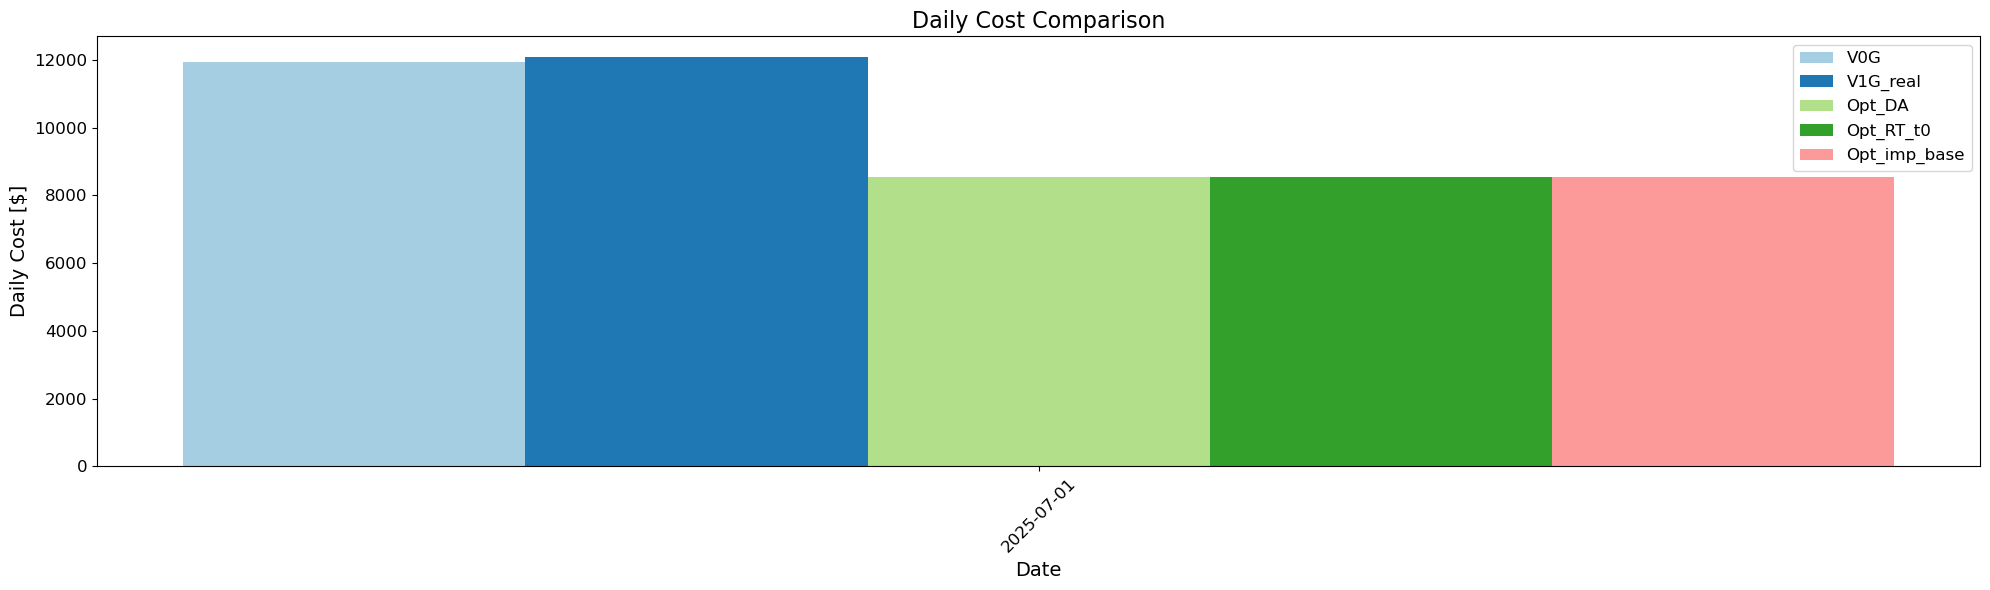

All cost checks passed for each day.

Correct cost rate: 100.00%
2025-07-01 cost types:
                cost  cost_NCD  cost_PD  cost_energy  revenue_DR  revenue_WM
V0G        11955.32   9182.06  2497.99       275.34        0.07        0.00
V1G_real   12094.01   8399.19  3418.69       276.28        0.15        0.00
Opt_DA      8540.06   6905.32  1359.78       275.20        0.24        0.00
Opt_RT_t0   8540.13   6905.32  1359.78       275.20        0.16      334.95
Base        8540.13   6905.32  1359.78       275.20        0.16      334.95
Case1       8540.13   6905.32  1359.78       275.20        0.16      334.95


In [259]:
# Test if dispatch have same daily energy
dir_Output = os.path.join('Results/Dispatch/' +H_Start_RT.strftime("%Y") +'_' +Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival +'_implementation.csv')
D_all_imp = pd.read_csv(dir_Output)
D_all_imp['Interval start'] = pd.to_datetime(D_all_imp['Interval start'])

all_dates = D_all_imp['Interval start'].dt.date.unique()
flag = True
for date in all_dates:
    D_day = D_all_imp[D_all_imp['Interval start'].dt.date == date]
    energies = [
        D_day['V0G [kWh]'].sum(),
        D_day['V1G_real [kWh]'].sum(),
        D_day['Opt_DA [kWh]'].sum(),
        D_day['Opt_RT_t0 [kWh]'].sum(),
        D_day['Base [kWh]'].sum()
    ]
    if not np.allclose(energies, energies[0], rtol=0.01):
        print(f"Energy mismatch on {date}: " +
              ", ".join([f"{col}={round(val,2)}" for col, val in zip(
                  ['V0G', 'V1G_real', 'Opt_DA', 'Opt_RT_t0', 'Opt_imp_base'], energies)]))
        flag = False

if flag:
    print("All energy checks passed for each day.")


# Show daily cost comparison
Cost_all_imp = pd.read_csv('Results/Dispatch/' + H_Start_RT.strftime("%Y") +'_' +Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival +'_daily_cost.csv')
Cost_all_imp['date'] = pd.to_datetime(Cost_all_imp['date'], format="%Y%m%d").dt.date

colors = sns.color_palette("Paired", 6)  # pastel colors
plt.figure(figsize=(20, 6))
x = np.arange(len(Cost_all_imp['date']))  # the label locations
width = 0.15  # the width of the bars
rects1 = plt.bar(x - 2*width, Cost_all_imp['V0G_cost'], width, label='V0G', color=colors[0])
rects2 = plt.bar(x - width, Cost_all_imp['V1G_real_cost'], width, label='V1G_real', color=colors[1])
rects3 = plt.bar(x, Cost_all_imp['Opt_DA_cost'], width, label='Opt_DA', color=colors[2])
rects4 = plt.bar(x + width, Cost_all_imp['Opt_RT_t0_cost'], width, label='Opt_RT_t0', color=colors[3])
rects5 = plt.bar(x + 2*width, Cost_all_imp['Base_cost'], width, label='Opt_imp_base', color=colors[4])
# rects6 = plt.bar(x + 3*width, Cost_all_imp['Case1_cost'], width, label='Opt_imp_case1', color=colors[5]) # not fair to compare
plt.xlabel('Date', fontsize=14)
plt.ylabel('Daily Cost [$]', fontsize=14)
plt.title('Daily Cost Comparison', fontsize=16)
plt.xticks(x, Cost_all_imp['date'].astype(str), rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()

path = 'Results/Plots/Cost/' + \
            H_Start_RT.strftime("%Y")+'_'+Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival + '/'

os.makedirs(path, exist_ok=True)
plt.savefig(path + 'daily_cost_comparison.png', dpi=300)
plt.show()
plt.close()


methods = ['V0G', 'V1G_real', 'Opt_DA', 'Opt_RT_t0', 'Base', 'Case1']
types = ['cost', 'cost_NCD', 'cost_PD', 'cost_energy', 'revenue_DR', 'revenue_WM']
# Compare each day if all methods have same type cost
flag_type = True
failures = 0
if Fc_SessionkWh == 'PerfectSessionkWh' and Fc_NumbEV == 'PerfectNumbEV' and Fc_AtArrival == 'PerfectatArrival':
    for t in types[1:]:
        for idx, row in Cost_all_imp.iterrows():
            costs = [row[m + '_' + t] for m in methods]
            costs_compare = [row[m + '_' + t] for m in methods[3:5]] # only compare Opt_RT_t0 and Base
            if not np.allclose(costs_compare, costs_compare[0], rtol=0.01):
                flag_type = False
                failures = failures + 1
                print(f"Cost type '{t}' mismatch on {row['date']}: " +
                      ", ".join([f"{m}={row[m + '_' + t]:.2f}" for m in methods[3:5]]))
if flag_type:
    print("All cost checks passed for each day.")
print("\nCorrect cost rate: {:.2f}%".format(100 * (1 - failures / len(Cost_all_imp))))

# Show sample day's cost types
df_cost_sample = pd.DataFrame()
date_cost = 1
sample_date = Cost_all_imp['date'].iloc[date_cost - 1]
Cost_sample = Cost_all_imp[Cost_all_imp['date'] == sample_date]
for m in methods:
    cost_method = Cost_sample.filter(like=m)
    cost_method.columns = types
    df_cost_sample = pd.concat([df_cost_sample, cost_method], axis=0, ignore_index=True)
    
df_cost_sample.index = methods
df_cost_sample = df_cost_sample.round(2)
df_cost_sample.to_csv('Other/' + f"cost_types_{sample_date}.csv", index=True)
print(sample_date, "cost types:\n", df_cost_sample)
